<a href="https://colab.research.google.com/github/RiaKodo/testbi/blob/main/Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
url = 'https://github.com/RiaKodo/testbi/raw/main/alamar_olink%20only.xlsx'
df = pd.read_excel(url)
display(df.head())

,ALAMAR_ID,ALAMAR_platepos,BIOAX_ID,GROUP,AGE,SEX,CCL11,MCP4,MCP1,CCL3,...,IL7_OLINK,IL10_OLINK,IL13_OLINK,IL17A_OLINK,IL18_OLINK,S100_A12_OLINK,TNF_OLINK,VEGFA_OLINK,IL6_IL10,IL6_IL10_OLINK
0,A_09_504089_Controls,A_09,504089,CON,43,Female,13.987254,13.451684,12.106203,8.640543,...,1.31139,1.52949,-1.47114,0.10145,8.15053,1.32965,2.63847,11.61742,-5.909322,-0.06233
1,A_10_504086_Controls,A_10,504086,CON,47,Male,15.186008,14.534820,13.019454,9.060234,...,1.34686,1.15437,-0.58082,-0.14630,7.82418,2.54657,2.56944,11.40506,-2.917068,1.50379
2,A_11_505260_Controls,A_11,505260,CON,37,Male,14.770383,14.551773,13.546072,8.323090,...,1.01801,0.67558,-1.37315,-0.40920,8.25509,1.53180,2.23006,11.59180,-4.712135,0.13694
3,B_01_505496_Controls,B_01,505496,CON,18,Male,14.012306,14.197147,12.387656,8.962086,...,1.85030,1.34336,-0.47112,0.75646,8.44195,6.41803,3.28226,11.80627,-3.876421,0.78121
4,B_04_505402_Controls,B_04,505402,CON,67,Male,15.374340,14.397764,13.443584,10.053066,...,0.59143,1.98544,-0.88305,-0.82783,8.42969,0.88071,3.75460,11.37357,-3.751047,0.75354


In [3]:
display(df.describe())

,BIOAX_ID,AGE,CCL11,MCP4,MCP1,CCL3,CCL4,CX3CL1,CXCL1,CXCL10,...,IL7_OLINK,IL10_OLINK,IL13_OLINK,IL17A_OLINK,IL18_OLINK,S100_A12_OLINK,TNF_OLINK,VEGFA_OLINK,IL6_IL10,IL6_IL10_OLINK
count,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,...,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000
mean,505010.593023,41.604651,14.595394,13.622185,13.716294,9.712394,11.368839,13.324872,13.236671,13.117073,...,1.140776,2.939451,-0.781003,0.106915,8.895145,3.729887,3.332815,12.157112,-2.328977,2.668584
std,645.087270,17.009533,0.526459,0.762703,1.077978,0.795843,0.884433,0.541249,0.977354,0.998734,...,0.701399,1.313386,0.707690,0.679238,0.534188,1.419213,0.456846,0.580524,2.126585,2.143775
min,503812.000000,18.000000,13.416508,11.478045,11.204845,8.323090,9.243009,12.466963,10.467183,10.888360,...,-0.665500,0.610970,-2.431360,-1.089280,7.219410,0.880710,2.230060,10.229420,-7.146142,-2.079440
25%,504140.250000,25.000000,14.225826,13.091091,13.053882,9.078874,10.876888,12.934613,12.616042,12.582145,...,0.609190,1.806637,-1.117457,-0.372265,8.467690,2.605133,3.070587,11.702040,-3.845077,0.842312
50%,505316.500000,41.000000,14.608372,13.661636,13.742443,9.535565,11.308833,13.232880,13.085036,12.977230,...,1.129375,2.928295,-0.839545,-0.011125,8.926490,3.632140,3.312395,12.190630,-2.060286,3.010955
75%,505468.000000,54.750000,14.987740,14.193584,14.138223,10.198116,12.005273,13.499999,13.849172,13.615844,...,1.549357,3.736535,-0.577497,0.465842,9.255900,4.606807,3.649542,12.542912,-0.619469,4.430850
max,505834.000000,73.000000,15.668485,15.607349,17.342421,11.650008,13.840884,15.319641,16.629563,17.094672,...,3.510550,7.200760,3.582140,2.532750,9.961480,6.791190,4.434990,13.433500,1.789845,6.956250


In [4]:
import pandas as pd
from scipy.stats import spearmanr
from statsmodels.stats.multitest import fdrcorrection

# Identify _OLINK columns and their non-_OLINK counterparts
olink_cols = [col for col in df.columns if col.endswith('_OLINK')]

correlation_pairs = []
for olink_col in olink_cols:
    non_olink_counterpart = None
    if olink_col == 'bNGF_OLINK':
        non_olink_counterpart = 'NGF'
    elif olink_col == 'S100_A12_OLINK':
        non_olink_counterpart = 'S100A12'
    elif olink_col == 'IFNg_OLINK':
        non_olink_counterpart = 'IFNG'
    else:
        non_olink_counterpart = olink_col.replace('_OLINK', '')

    # Only add to pairs if both columns exist in the DataFrame
    if non_olink_counterpart in df.columns:
        correlation_pairs.append((non_olink_counterpart, olink_col))

print(f"Found {len(correlation_pairs)} pairs for correlation analysis.")

Found 25 pairs for correlation analysis.


In [5]:
# Calculate Spearman's correlation and p-values for each pair
results = []
p_values = []

for non_olink_col, olink_col in correlation_pairs:
    # Ensure there are no NaNs in the columns for correlation calculation
    # or handle them as per requirement (e.g., dropna, fillna)
    # For simplicity, using pairwise deletion for spearmanr, which handles NaNs by default.
    rho, p_value = spearmanr(df[non_olink_col], df[olink_col], nan_policy='omit')
    results.append({
        'Protein Pair': f"{non_olink_col} vs {olink_col}",
        'Spearman Rho': rho,
        'Original P-value': p_value
    })
    p_values.append(p_value)

# Apply FDR correction if there are p-values to correct
if p_values:
    # fdrcorrection returns (reject, pvals_corrected)
    # reject is a boolean array indicating if the hypothesis is rejected for a given alpha (default 0.05)
    reject, p_values_corrected = fdrcorrection(p_values, alpha=0.05)
    for i, res in enumerate(results):
        res['FDR Corrected P-value'] = p_values_corrected[i]
        res['Significant (FDR < 0.05)'] = reject[i]

# Convert results to a DataFrame for better display
correlation_df = pd.DataFrame(results)

display(correlation_df.sort_values(by='FDR Corrected P-value'))

,Protein Pair,Spearman Rho,Original P-value,FDR Corrected P-value,Significant (FDR < 0.05)
15,IL6 vs IL6_OLINK,0.978282,3.454293e-59,8.635734e-58,True
24,IL6_IL10 vs IL6_IL10_OLINK,0.952583,3.581343e-45,4.476679e-44,True
11,IFNG vs IFNg_OLINK,0.943809,3.737365e-42,3.114471e-41,True
8,MCP4 vs MCP4_OLINK,0.942224,1.163531e-41,7.272068e-41,True
17,IL10 vs IL10_OLINK,0.939620,7.023585e-41,3.511793e-40,True
16,IL7 vs IL7_OLINK,0.895825,2.503794e-31,1.043247e-30,True
1,CCL3 vs CCL3_OLINK,0.894712,3.822082e-31,1.365029e-30,True
7,MCP1 vs MCP1_OLINK,0.883995,1.786889e-29,5.584030e-29,True
4,CXCL10 vs CXCL10_OLINK,0.881542,4.084865e-29,1.134685e-28,True
21,S100A12 vs S100_A12_OLINK,0.856333,7.881474e-26,1.970368e-25,True


### Overall Spearman's Correlation Heatmap

First, let's visualize the overall Spearman's correlations for the identified protein pairs using a heatmap, sorted by the Spearman Rho value from highest to lowest.

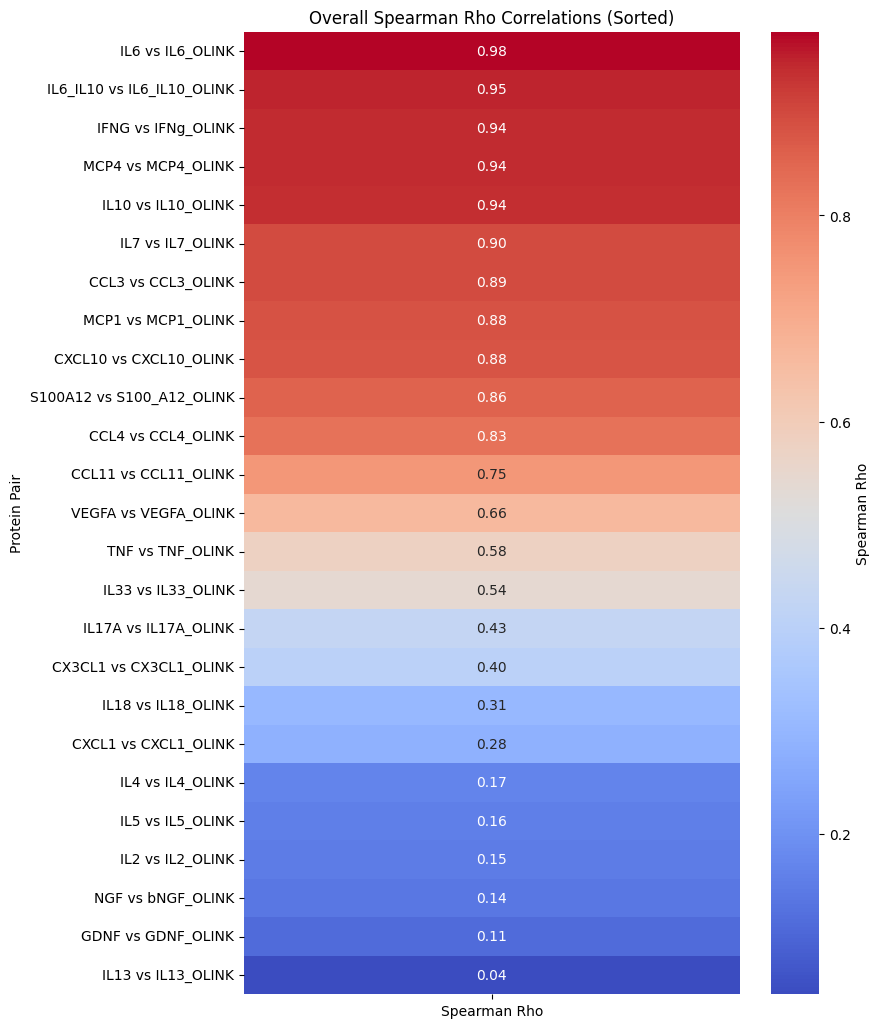

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the correlation_df by 'Spearman Rho' for the heatmap visualization
correlation_df_sorted = correlation_df.sort_values(by='Spearman Rho', ascending=False).set_index('Protein Pair')

plt.figure(figsize=(8, correlation_df_sorted.shape[0] * 0.5))
sns.heatmap(correlation_df_sorted[['Spearman Rho']], annot=True, cmap='coolwarm', fmt=".2f", cbar_kws={'label': 'Spearman Rho'})
plt.title('Overall Spearman Rho Correlations (Sorted)')
plt.ylabel('Protein Pair')
plt.show()

### Subgroup Correlation Analysis

Now, let's perform the same FDR-corrected Spearman's correlation analysis for each subgroup: NTT, TBI, HC, males, and females. We'll define a function to encapsulate the correlation logic to apply it consistently across all subgroups.

In [7]:
# Define a function to perform the correlation analysis for a given DataFrame subset
def calculate_spearman_fdr(data_df, correlation_pairs, subset_name):
    results = []
    p_values = []

    for non_olink_col, olink_col in correlation_pairs:
        # Ensure there are no NaNs in the columns for correlation calculation
        rho, p_value = spearmanr(data_df[non_olink_col], data_df[olink_col], nan_policy='omit')
        results.append({
            'Protein Pair': f"{non_olink_col} vs {olink_col}",
            f'{subset_name}_Spearman Rho': rho,
            f'{subset_name}_Original P-value': p_value
        })
        p_values.append(p_value)

    if p_values:
        reject, p_values_corrected = fdrcorrection(p_values, alpha=0.05)
        for i, res in enumerate(results):
            res[f'{subset_name}_FDR Corrected P-value'] = p_values_corrected[i]
            res[f'{subset_name}_Significant (FDR < 0.05)'] = reject[i]

    return pd.DataFrame(results)

# Get unique groups and sexes
groups = df['GROUP'].unique()
sexes = df['SEX'].unique()

all_subgroup_correlations = []

# Run correlation for the overall dataframe to have a baseline in the combined view
overall_corr_df = calculate_spearman_fdr(df, correlation_pairs, 'Overall')
all_subgroup_correlations.append(overall_corr_df)

# Run correlation for each GROUP subgroup
for group in groups:
    group_df = df[df['GROUP'] == group].copy()
    if not group_df.empty:
        group_corr_df = calculate_spearman_fdr(group_df, correlation_pairs, group)
        all_subgroup_correlations.append(group_corr_df)
    else:
        print(f"No data for group: {group}")

# Run correlation for each SEX subgroup
for sex in sexes:
    sex_df = df[df['SEX'] == sex].copy()
    if not sex_df.empty:
        sex_corr_df = calculate_spearman_fdr(sex_df, correlation_pairs, sex)
        all_subgroup_correlations.append(sex_corr_df)
    else:
        print(f"No data for sex: {sex}")

# Merge all correlation results into a single DataFrame
combined_correlations_df = all_subgroup_correlations[0]
for i in range(1, len(all_subgroup_correlations)):
    combined_correlations_df = pd.merge(
        combined_correlations_df,
        all_subgroup_correlations[i],
        on='Protein Pair',
        how='outer'
    )

# Sort by 'Overall_Spearman Rho' for consistent ordering
combined_correlations_df = combined_correlations_df.sort_values(by='Overall_Spearman Rho', ascending=False)

display(combined_correlations_df.head())


,Protein Pair,Overall_Spearman Rho,Overall_Original P-value,Overall_FDR Corrected P-value,Overall_Significant (FDR < 0.05),CON_Spearman Rho,CON_Original P-value,CON_FDR Corrected P-value,CON_Significant (FDR < 0.05),NTT_Spearman Rho,...,TBI_FDR Corrected P-value,TBI_Significant (FDR < 0.05),Female_Spearman Rho,Female_Original P-value,Female_FDR Corrected P-value,Female_Significant (FDR < 0.05),Male_Spearman Rho,Male_Original P-value,Male_FDR Corrected P-value,Male_Significant (FDR < 0.05)
16,IL6 vs IL6_OLINK,0.978282,3.454293e-59,8.635734e-58,True,0.932308,4.311800e-12,5.389750e-11,True,0.848673,...,1.433915e-18,True,0.917582,9.906225e-06,3.537938e-05,True,0.989788,8.139407e-62,2.034852e-60,True
17,IL6_IL10 vs IL6_IL10_OLINK,0.952583,3.581343e-45,4.476679e-44,True,0.889231,1.265975e-09,7.912345e-09,True,0.805759,...,2.806810e-18,True,0.763736,2.376615e-03,5.401397e-03,True,0.969456,4.489080e-45,5.611350e-44,True
7,IFNG vs IFNg_OLINK,0.943809,3.737365e-42,3.114471e-41,True,0.947350,2.285490e-13,5.713725e-12,True,0.975155,...,2.938242e-17,True,0.978022,7.757814e-09,1.939454e-07,True,0.937801,2.402650e-34,2.002208e-33,True
20,MCP4 vs MCP4_OLINK,0.942224,1.163531e-41,7.272068e-41,True,0.908376,1.437623e-10,1.198019e-09,True,0.918690,...,7.239111e-16,True,0.928571,4.607427e-06,1.919761e-05,True,0.937029,3.672077e-34,2.295048e-33,True
8,IL10 vs IL10_OLINK,0.939620,7.023585e-41,3.511793e-40,True,0.768889,4.454387e-06,1.113597e-05,True,0.934500,...,1.638368e-15,True,0.928571,4.607427e-06,1.919761e-05,True,0.935086,1.044730e-33,5.223650e-33,True


### Combined Heatmap of Spearman Rho Across Subgroups

Finally, here's a heatmap visualizing the Spearman Rho values for all protein pairs across the overall dataset and each subgroup (NTT, TBI, HC, Male, Female). Protein pairs are ordered by their 'Overall' Spearman Rho.

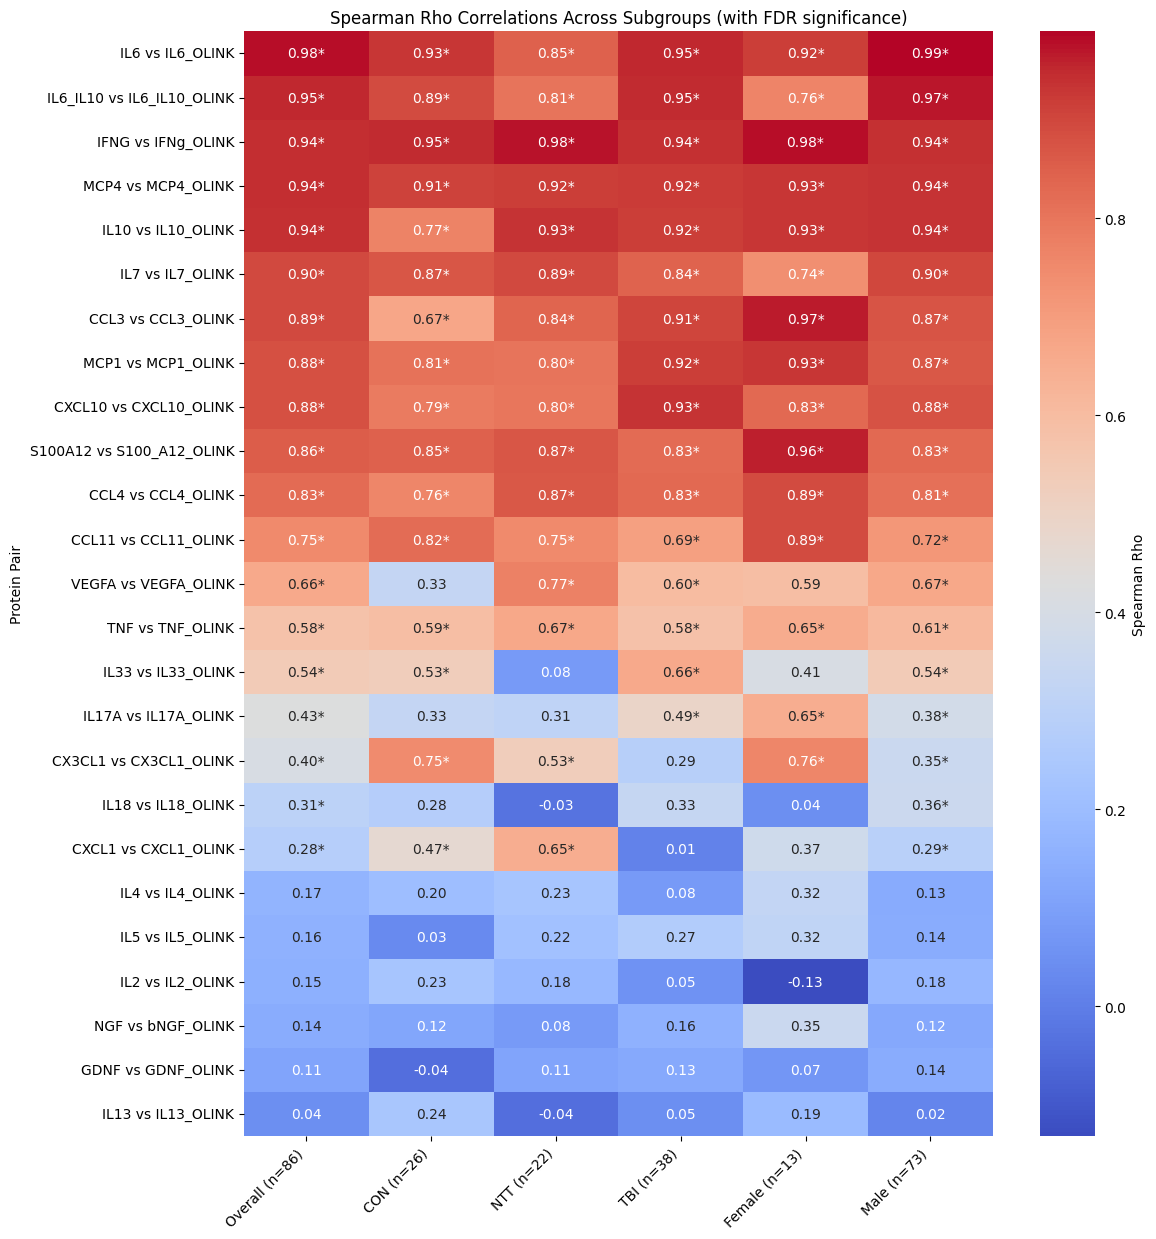

In [8]:
# Extract only the Spearman Rho columns for the heatmap
spearman_rho_cols = [col for col in combined_correlations_df.columns if 'Spearman Rho' in col]
heatmap_data = combined_correlations_df[['Protein Pair'] + spearman_rho_cols].set_index('Protein Pair')

# Calculate subgroup counts for 'n' values
subgroup_counts = {
    'Overall': len(df),
    'CON': len(df[df['GROUP'] == 'CON']),
    'NTT': len(df[df['GROUP'] == 'NTT']),
    'TBI': len(df[df['GROUP'] == 'TBI']),
    'Female': len(df[df['SEX'] == 'Female']),
    'Male': len(df[df['SEX'] == 'Male'])
}

# Create new x-axis labels with (n=X)
xtick_labels = []
for col_name in heatmap_data.columns:
    # Extract the subgroup name from the column name (e.g., 'Overall_Spearman Rho' -> 'Overall')
    subgroup_key = col_name.replace('_Spearman Rho', '')
    if subgroup_key in subgroup_counts:
        xtick_labels.append(f"{subgroup_key} (n={subgroup_counts[subgroup_key]})")
    else:
        xtick_labels.append(subgroup_key) # Fallback if for some reason a key is not found

# Create an annotation DataFrame
annotation_data = pd.DataFrame(index=heatmap_data.index, columns=heatmap_data.columns)

for col in spearman_rho_cols:
    subset_name = col.replace('_Spearman Rho', '')
    significant_col = f'{subset_name}_Significant (FDR < 0.05)'
    for protein_pair in heatmap_data.index:
        rho = heatmap_data.loc[protein_pair, col]
        # Check if the significant column exists in combined_correlations_df
        if significant_col in combined_correlations_df.columns:
            is_significant = combined_correlations_df.loc[combined_correlations_df['Protein Pair'] == protein_pair, significant_col].iloc[0]
        else:
            is_significant = False # Assume not significant if column doesn't exist

        if pd.notna(rho):
            annotation_data.loc[protein_pair, col] = f"{rho:.2f}" + ('*' if is_significant else '')
        else:
            annotation_data.loc[protein_pair, col] = '' # Handle NaN or missing rho values

plt.figure(figsize=(12, heatmap_data.shape[0] * 0.5))
sns.heatmap(heatmap_data, annot=annotation_data, cmap='coolwarm', fmt="", cbar_kws={'label': 'Spearman Rho'}, xticklabels=xtick_labels)
plt.title('Spearman Rho Correlations Across Subgroups (with FDR significance)')
plt.ylabel('Protein Pair')
plt.xlabel('') # Removing xlabel as xticklabels are self-explanatory
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save the figure as an image
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

### Combined Spearman Rho and FDR Corrected P-values Across Subgroups

To view both Spearman Rho and their FDR Corrected P-values clearly, here is a table displaying these metrics for all protein pairs across the overall dataset and each subgroup. The pairs are sorted by their 'Overall' Spearman Rho.

### Comparative Box Plots for Protein Pairs with Differing Significance

This section identifies protein pairs where the significance of their correlation (FDR < 0.05) varies across different subgroups (Overall, CON, NTT, TBI, Female, Male). For each such pair, a comparative box plot is generated to visualize the distribution of expression values for both the non-OLINK and OLINK proteins across these groups. This allows for a deeper understanding of the context-dependent relationships between these protein measurements.

Found 6 protein pairs with differing significance across subgroups:
['VEGFA vs VEGFA_OLINK', 'IL33 vs IL33_OLINK', 'IL17A vs IL17A_OLINK', 'CX3CL1 vs CX3CL1_OLINK', 'IL18 vs IL18_OLINK', 'CXCL1 vs CXCL1_OLINK']


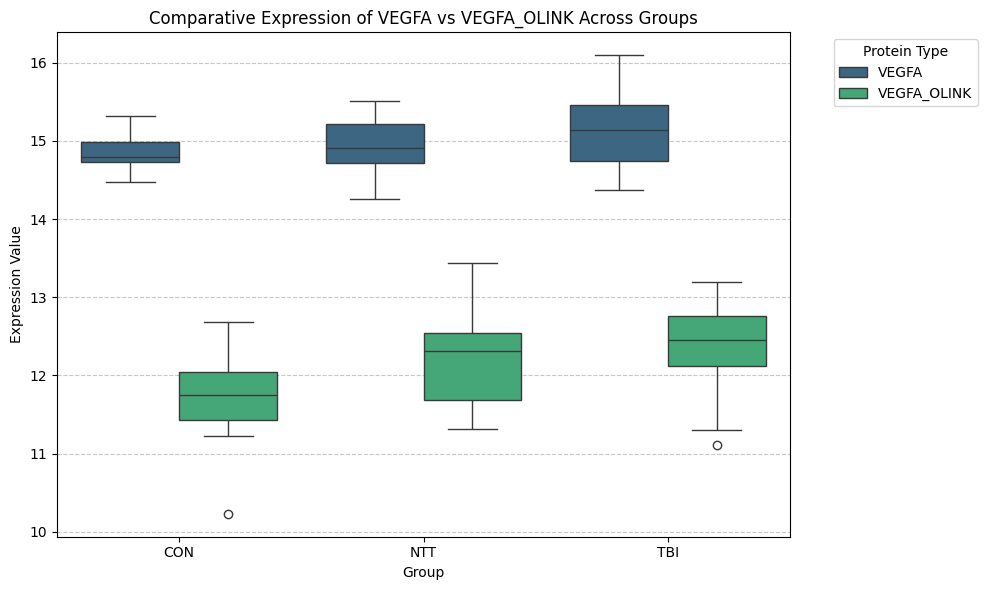

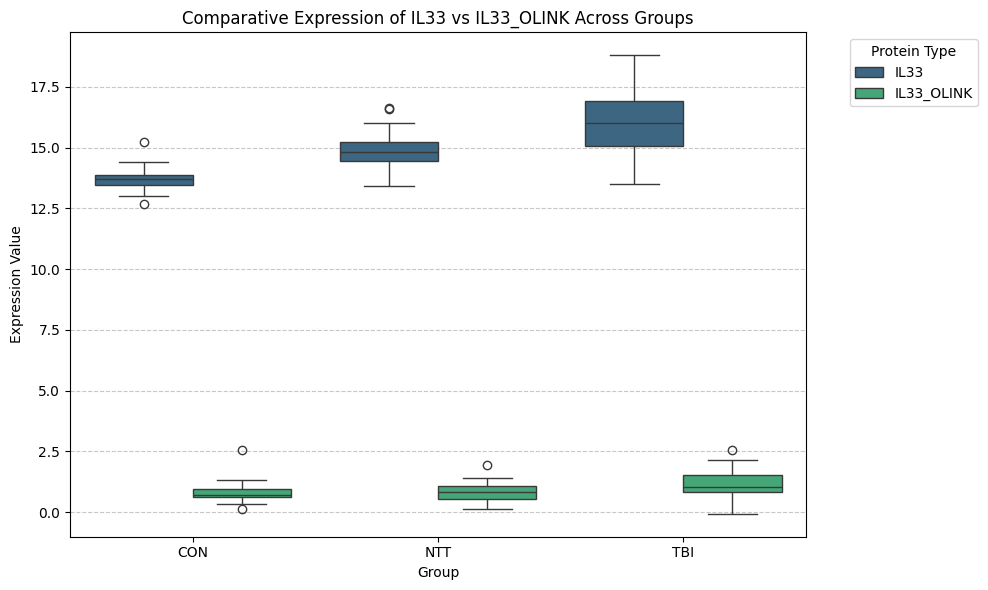

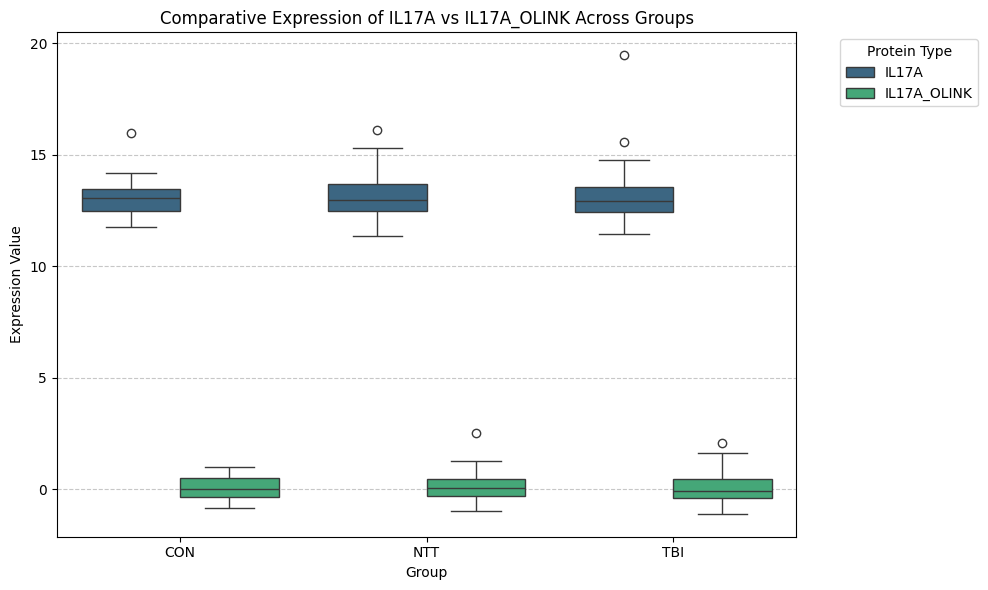

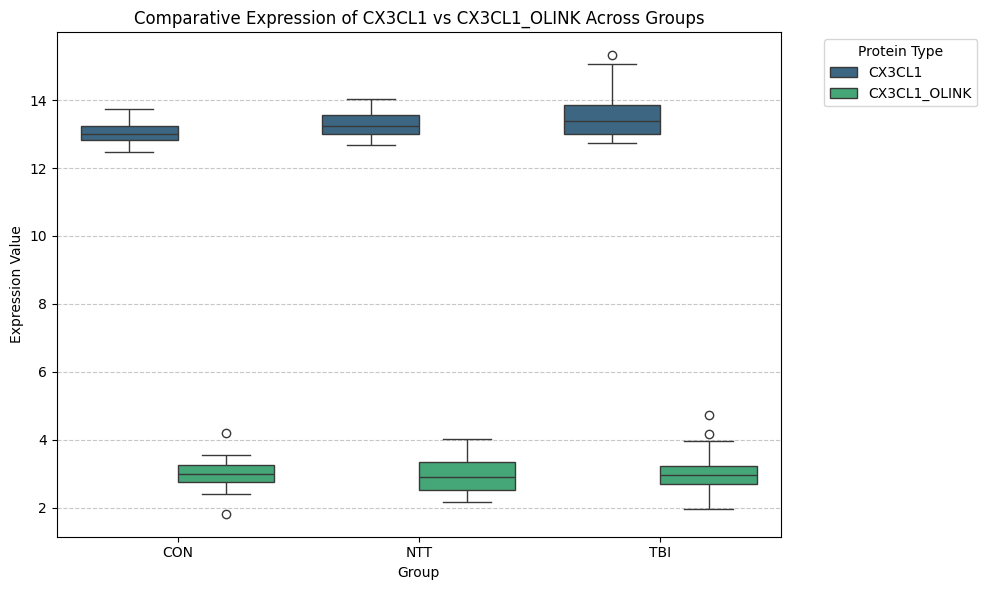

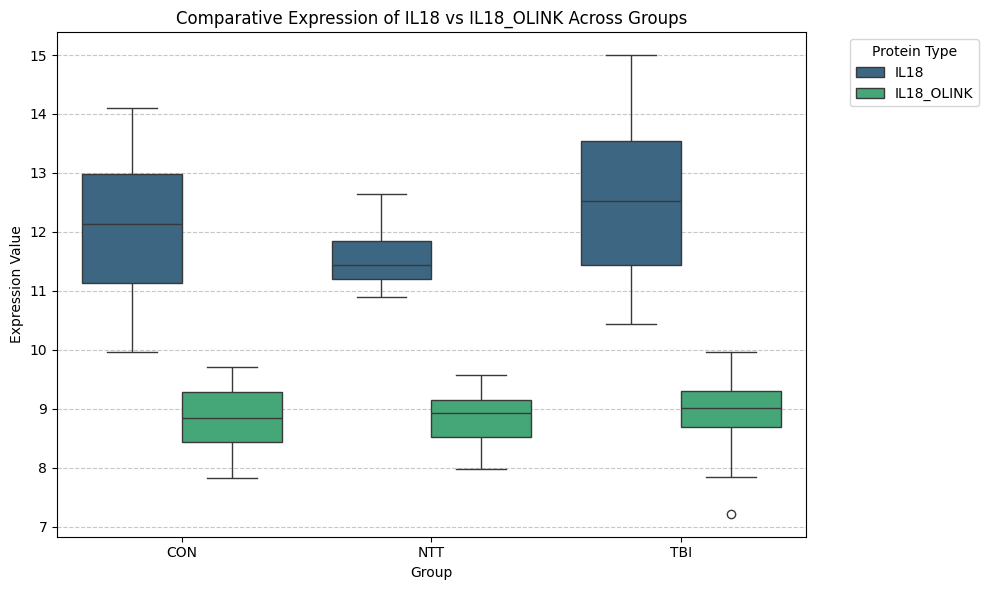

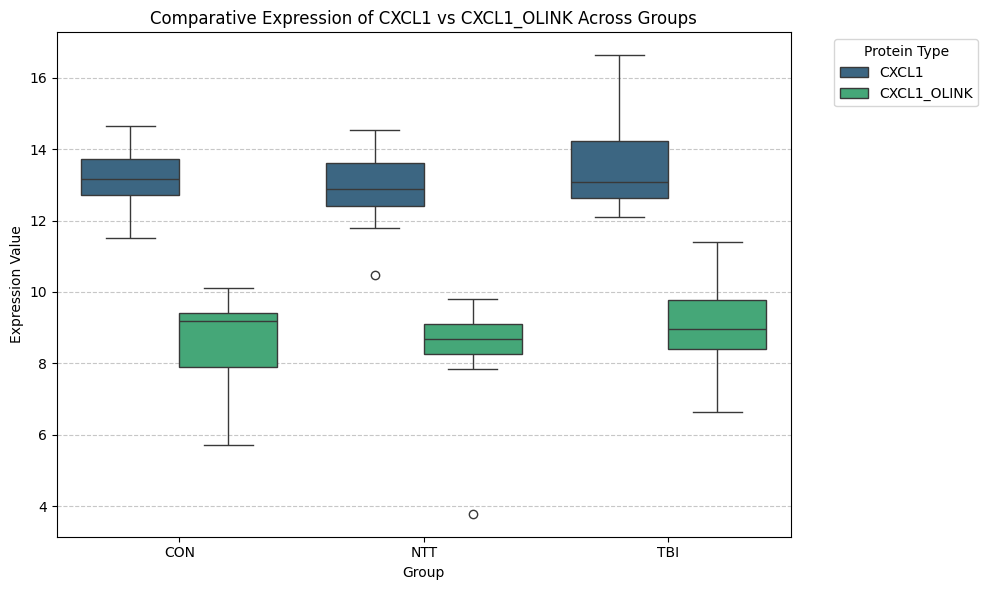

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify significance columns from combined_correlations_df
significance_cols = [col for col in combined_correlations_df.columns if '_Significant (FDR < 0.05)' in col]

differing_significance_pairs = []

# Find protein pairs where significance varies across subgroups
for index, row in combined_correlations_df.iterrows():
    sig_values = [row[col] for col in significance_cols]
    # If there's more than one unique significance status (True/False or NaN), add to list
    # Filtering out NaN values before checking for uniqueness to handle cases where a subgroup might not have data
    clean_sig_values = [s for s in sig_values if pd.notna(s)]
    if len(set(clean_sig_values)) > 1:
        differing_significance_pairs.append(row['Protein Pair'])

print(f"Found {len(differing_significance_pairs)} protein pairs with differing significance across subgroups:\n{differing_significance_pairs}")

# Generate box plots for each identified pair
for protein_pair_str in differing_significance_pairs:
    non_olink_col = None
    olink_col = None

    # Extract non-OLINK and OLINK column names from the protein pair string
    # Using the 'correlation_pairs' list for accurate mapping
    for np_col, op_col in correlation_pairs:
        if f"{np_col} vs {op_col}" == protein_pair_str:
            non_olink_col = np_col
            olink_col = op_col
            break

    if non_olink_col and olink_col:
        # Select relevant columns from the original DataFrame and melt for plotting
        plot_df = df[['GROUP', non_olink_col, olink_col]].copy()

        # Convert protein expression columns to numeric, coercing errors to NaN
        plot_df[non_olink_col] = pd.to_numeric(plot_df[non_olink_col], errors='coerce')
        plot_df[olink_col] = pd.to_numeric(plot_df[olink_col], errors='coerce')

        plot_df_melted = plot_df.melt(id_vars=['GROUP'], var_name='Protein', value_name='Expression')

        plt.figure(figsize=(10, 6))
        sns.boxplot(data=plot_df_melted, x='GROUP', y='Expression', hue='Protein', palette='viridis')
        plt.title(f'Comparative Expression of {protein_pair_str} Across Groups')
        plt.ylabel('Expression Value')
        plt.xlabel('Group')
        plt.legend(title='Protein Type', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Could not find corresponding columns for pair: {protein_pair_str}")

In [10]:
# Select only the Spearman Rho and FDR Corrected P-value columns for display
display_cols = ['Protein Pair']
for col in combined_correlations_df.columns:
    if 'Spearman Rho' in col or 'FDR Corrected P-value' in col:
        display_cols.append(col)

display(combined_correlations_df[display_cols].head(10)) # Displaying first 10 rows for brevity

,Protein Pair,Overall_Spearman Rho,Overall_FDR Corrected P-value,CON_Spearman Rho,CON_FDR Corrected P-value,NTT_Spearman Rho,NTT_FDR Corrected P-value,TBI_Spearman Rho,TBI_FDR Corrected P-value,Female_Spearman Rho,Female_FDR Corrected P-value,Male_Spearman Rho,Male_FDR Corrected P-value
16,IL6 vs IL6_OLINK,0.978282,8.635734e-58,0.932308,5.389750e-11,0.848673,2.140329e-06,0.951198,1.433915e-18,0.917582,3.537938e-05,0.989788,2.034852e-60
17,IL6_IL10 vs IL6_IL10_OLINK,0.952583,4.476679e-44,0.889231,7.912345e-09,0.805759,1.672479e-05,0.947259,2.806810e-18,0.763736,5.401397e-03,0.969456,5.611350e-44
7,IFNG vs IFNg_OLINK,0.943809,3.114471e-41,0.947350,5.713725e-12,0.975155,3.649262e-13,0.938286,2.938242e-17,0.978022,1.939454e-07,0.937801,2.002208e-33
20,MCP4 vs MCP4_OLINK,0.942224,7.272068e-41,0.908376,1.198019e-09,0.918690,1.353797e-08,0.923624,7.239111e-16,0.928571,1.919761e-05,0.937029,2.295048e-33
8,IL10 vs IL10_OLINK,0.939620,3.511793e-40,0.768889,1.113597e-05,0.934500,2.497978e-09,0.918372,1.638368e-15,0.928571,1.919761e-05,0.935086,5.223650e-33
18,IL7 vs IL7_OLINK,0.895825,1.043247e-30,0.870085,3.870201e-08,0.893845,1.314041e-07,0.843965,7.855339e-11,0.736264,7.899441e-03,0.897908,2.177047e-26
1,CCL3 vs CCL3_OLINK,0.894712,1.365029e-30,0.673846,3.091111e-04,0.840768,3.010272e-06,0.905241,1.882002e-14,0.967033,8.830142e-07,0.872732,2.613900e-23
19,MCP1 vs MCP1_OLINK,0.883995,5.584030e-29,0.807179,1.961101e-06,0.802372,1.687743e-05,0.918809,1.638368e-15,0.928571,1.919761e-05,0.866870,1.034885e-22
5,CXCL10 vs CXCL10_OLINK,0.881542,1.134685e-28,0.788034,4.880550e-06,0.801242,1.687743e-05,0.933034,9.177681e-17,0.829670,1.125716e-03,0.876681,1.046835e-23
22,S100A12 vs S100_A12_OLINK,0.856333,1.970368e-25,0.847521,1.950712e-07,0.870130,7.129495e-07,0.827552,3.372097e-10,0.961538,1.359807e-06,0.829785,2.928921e-19


### Kendall's Tau Correlation Analysis Across Subgroups

Now, let's perform the same FDR-corrected correlation analysis using Kendall's tau for the overall dataset and each subgroup (NTT, TBI, HC, males, and females). We'll define a function to encapsulate the Kendall correlation logic to apply it consistently across all subgroups.

In [11]:
from scipy.stats import kendalltau

# Define a function to perform the Kendall correlation analysis for a given DataFrame subset
def calculate_kendall_fdr(data_df, correlation_pairs, subset_name):
    results = []
    p_values = []

    for non_olink_col, olink_col in correlation_pairs:
        # Ensure there are no NaNs in the columns for correlation calculation
        # Using pairwise deletion for kendalltau, which handles NaNs by default.
        # Convert protein expression columns to numeric, coercing errors to NaN
        data_df[non_olink_col] = pd.to_numeric(data_df[non_olink_col], errors='coerce')
        data_df[olink_col] = pd.to_numeric(data_df[olink_col], errors='coerce')

        # Drop rows with NaNs for this specific pair to ensure valid correlation calculation
        temp_df = data_df[[non_olink_col, olink_col]].dropna()

        if not temp_df.empty:
            tau, p_value = kendalltau(temp_df[non_olink_col], temp_df[olink_col])
            results.append({
                'Protein Pair': f"{non_olink_col} vs {olink_col}",
                f'{subset_name}_Kendall Tau': tau,
                f'{subset_name}_Original P-value': p_value
            })
            p_values.append(p_value)
        else:
            # If no valid data, append NaN results for consistency
            results.append({
                'Protein Pair': f"{non_olink_col} vs {olink_col}",
                f'{subset_name}_Kendall Tau': float('nan'),
                f'{subset_name}_Original P-value': float('nan')
            })
            p_values.append(float('nan')) # Append NaN for p_value too

    # Filter out NaN p-values before FDR correction
    valid_p_values_indices = [i for i, p in enumerate(p_values) if pd.notna(p)]
    valid_p_values = [p_values[i] for i in valid_p_values_indices]

    if valid_p_values:
        reject, p_values_corrected = fdrcorrection(valid_p_values, alpha=0.05)
        # Map corrected p-values back to the original results list
        corrected_p_value_iter = iter(p_values_corrected)
        significant_iter = iter(reject)
        for i, res in enumerate(results):
            if i in valid_p_values_indices:
                res[f'{subset_name}_FDR Corrected P-value'] = next(corrected_p_value_iter)
                res[f'{subset_name}_Significant (FDR < 0.05)'] = next(significant_iter)
            else:
                res[f'{subset_name}_FDR Corrected P-value'] = float('nan')
                res[f'{subset_name}_Significant (FDR < 0.05)'] = False # Or float('nan') if preferred

    return pd.DataFrame(results)

# Get unique groups and sexes
groups = df['GROUP'].unique()
sexes = df['SEX'].unique()

all_subgroup_kendall_correlations = []

# Run correlation for the overall dataframe to have a baseline in the combined view
overall_kendall_corr_df = calculate_kendall_fdr(df.copy(), correlation_pairs, 'Overall') # Use .copy() to avoid modifying original df
all_subgroup_kendall_correlations.append(overall_kendall_corr_df)

# Run correlation for each GROUP subgroup
for group in groups:
    group_df = df[df['GROUP'] == group].copy()
    if not group_df.empty:
        group_kendall_corr_df = calculate_kendall_fdr(group_df, correlation_pairs, group)
        all_subgroup_kendall_correlations.append(group_kendall_corr_df)
    else:
        print(f"No data for group: {group}")

# Run correlation for each SEX subgroup
for sex in sexes:
    sex_df = df[df['SEX'] == sex].copy()
    if not sex_df.empty:
        sex_kendall_corr_df = calculate_kendall_fdr(sex_df, correlation_pairs, sex)
        all_subgroup_kendall_correlations.append(sex_kendall_corr_df)
    else:
        print(f"No data for sex: {sex}")

# Merge all Kendall correlation results into a single DataFrame
combined_kendall_correlations_df = all_subgroup_kendall_correlations[0]
for i in range(1, len(all_subgroup_kendall_correlations)):
    combined_kendall_correlations_df = pd.merge(
        combined_kendall_correlations_df,
        all_subgroup_kendall_correlations[i],
        on='Protein Pair',
        how='outer'
    )

# Sort by 'Overall_Kendall Tau' for consistent ordering
combined_kendall_correlations_df = combined_kendall_correlations_df.sort_values(by='Overall_Kendall Tau', ascending=False)

display(combined_kendall_correlations_df.head())

,Protein Pair,Overall_Kendall Tau,Overall_Original P-value,Overall_FDR Corrected P-value,Overall_Significant (FDR < 0.05),CON_Kendall Tau,CON_Original P-value,CON_FDR Corrected P-value,CON_Significant (FDR < 0.05),NTT_Kendall Tau,...,TBI_FDR Corrected P-value,TBI_Significant (FDR < 0.05),Female_Kendall Tau,Female_Original P-value,Female_FDR Corrected P-value,Female_Significant (FDR < 0.05),Male_Kendall Tau,Male_Original P-value,Male_FDR Corrected P-value,Male_Significant (FDR < 0.05)
16,IL6 vs IL6_OLINK,0.909166,2.806582e-35,7.016456e-34,True,0.784615,1.030182e-10,1.287728e-09,True,0.792208,...,1.262973e-12,True,0.794872,3.192923e-05,0.000133,True,0.928463,3.257485e-31,8.143712e-30,True
17,IL6_IL10 vs IL6_IL10_OLINK,0.851163,3.953239e-31,4.941548e-30,True,0.741538,2.432861e-09,1.520538e-08,True,0.705628,...,3.484528e-12,True,0.615385,2.675523e-03,0.004778,True,0.869102,1.480778e-27,1.850973e-26,True
7,IFNG vs IFNg_OLINK,0.829275,1.237228e-29,1.031023e-28,True,0.827692,2.374154e-12,5.935386e-11,True,0.896104,...,4.059318e-12,True,0.923077,1.416408e-07,0.000004,True,0.818113,1.325669e-24,1.104724e-23,True
8,IL10 vs IL10_OLINK,0.793707,2.759211e-27,1.724507e-26,True,0.606154,3.866063e-06,9.665158e-06,True,0.792208,...,2.564210e-11,True,0.846154,5.202488e-06,0.000033,True,0.781583,1.347389e-22,8.421180e-22,True
20,MCP4 vs MCP4_OLINK,0.790971,4.142192e-27,2.071096e-26,True,0.760000,6.685266e-10,5.571055e-09,True,0.783550,...,3.700249e-11,True,0.794872,3.192923e-05,0.000133,True,0.779300,1.786277e-22,8.931387e-22,True


### Combined Heatmap of Kendall's Tau Across Subgroups

Here's a heatmap visualizing the Kendall's Tau values for all protein pairs across the overall dataset and each subgroup (CON, NTT, TBI, Female, Male). Protein pairs are ordered by their 'Overall' Kendall Tau. Significance (FDR < 0.05) is indicated by an asterisk (*), and subgroup sample sizes are included in the x-axis labels.

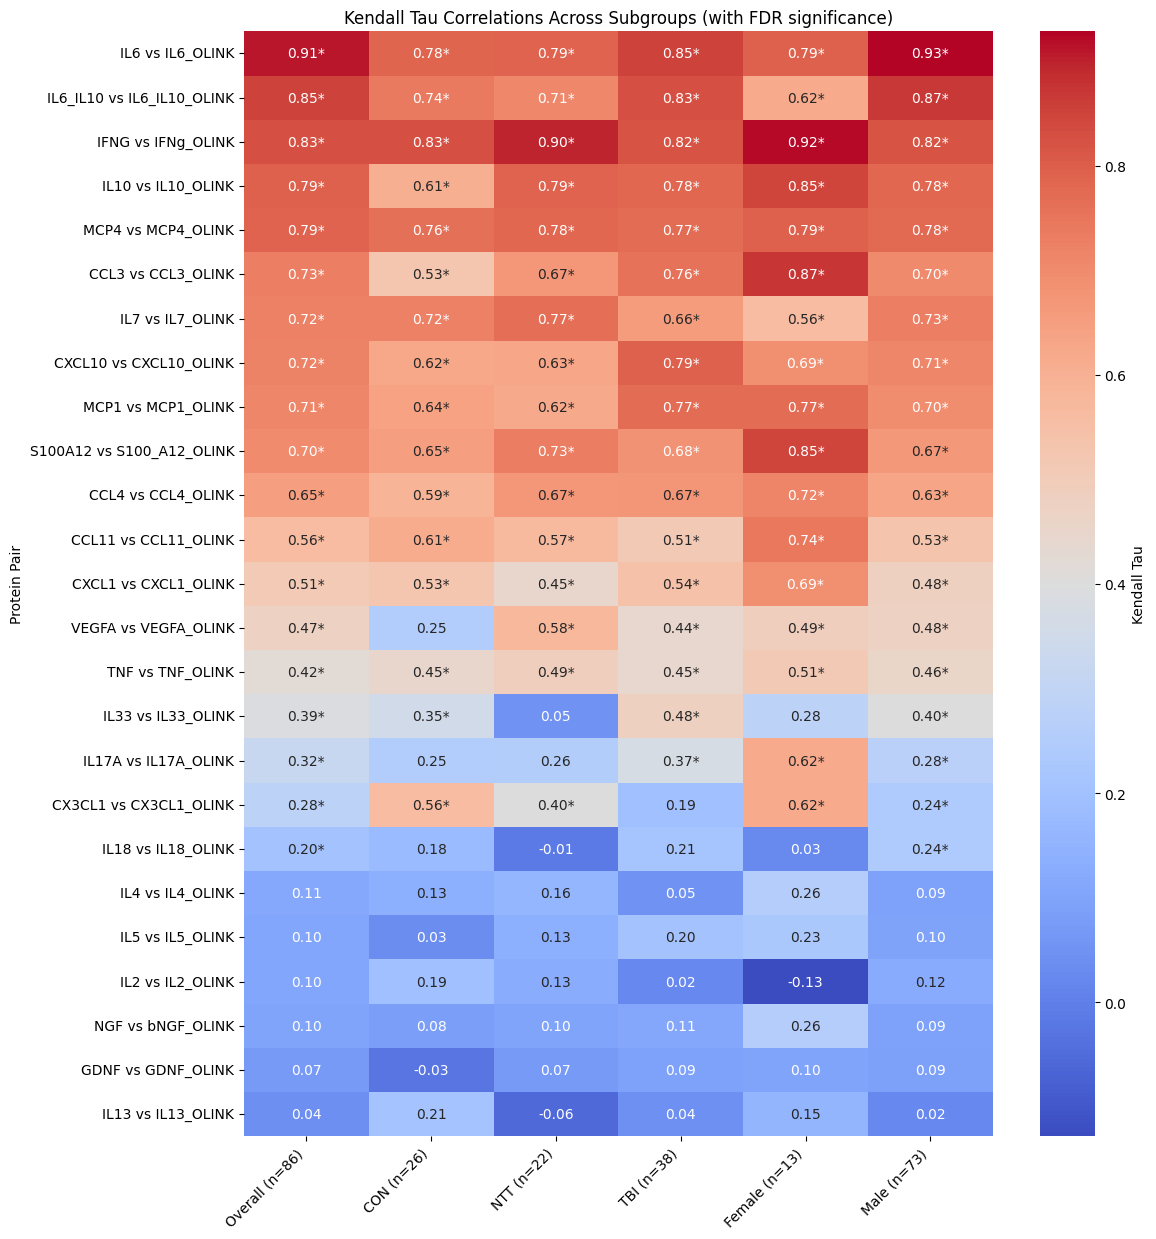

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract only the Kendall Tau columns for the heatmap
kendall_tau_cols = [col for col in combined_kendall_correlations_df.columns if 'Kendall Tau' in col]
heatmap_kendall_data = combined_kendall_correlations_df[['Protein Pair'] + kendall_tau_cols].set_index('Protein Pair')

# Calculate subgroup counts for 'n' values (assuming the same counts as for Spearman's analysis)
subgroup_counts = {
    'Overall': len(df),
    'CON': len(df[df['GROUP'] == 'CON']),
    'NTT': len(df[df['GROUP'] == 'NTT']),
    'TBI': len(df[df['GROUP'] == 'TBI']),
    'Female': len(df[df['SEX'] == 'Female']),
    'Male': len(df[df['SEX'] == 'Male'])
}

# Create new x-axis labels with (n=X)
xtick_labels_kendall = []
for col_name in heatmap_kendall_data.columns:
    # Extract the subgroup name from the column name (e.g., 'Overall_Kendall Tau' -> 'Overall')
    subgroup_key = col_name.replace('_Kendall Tau', '')
    if subgroup_key in subgroup_counts:
        xtick_labels_kendall.append(f"{subgroup_key} (n={subgroup_counts[subgroup_key]})")
    else:
        xtick_labels_kendall.append(subgroup_key) # Fallback if for some reason a key is not found

# Create an annotation DataFrame for Kendall's Tau
annotation_kendall_data = pd.DataFrame(index=heatmap_kendall_data.index, columns=heatmap_kendall_data.columns)

for col in kendall_tau_cols:
    subset_name = col.replace('_Kendall Tau', '')
    significant_col = f'{subset_name}_Significant (FDR < 0.05)'
    for protein_pair in heatmap_kendall_data.index:
        tau_value = heatmap_kendall_data.loc[protein_pair, col]
        # Check if the significant column exists in combined_kendall_correlations_df
        # Use .loc to select the correct row based on 'Protein Pair' and then .iloc[0] to get the value
        if significant_col in combined_kendall_correlations_df.columns:
            is_significant = combined_kendall_correlations_df.loc[combined_kendall_correlations_df['Protein Pair'] == protein_pair, significant_col].iloc[0]
        else:
            is_significant = False # Assume not significant if column doesn't exist

        if pd.notna(tau_value):
            annotation_kendall_data.loc[protein_pair, col] = f"{tau_value:.2f}" + ('*' if is_significant else '')
        else:
            annotation_kendall_data.loc[protein_pair, col] = '' # Handle NaN or missing tau values

plt.figure(figsize=(12, heatmap_kendall_data.shape[0] * 0.5))
sns.heatmap(heatmap_kendall_data, annot=annotation_kendall_data, cmap='coolwarm', fmt="", cbar_kws={'label': 'Kendall Tau'}, xticklabels=xtick_labels_kendall)
plt.title('Kendall Tau Correlations Across Subgroups (with FDR significance)')
plt.ylabel('Protein Pair')
plt.xlabel('') # Removing xlabel as xticklabels are self-explanatory
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save the figure as an image
plt.savefig('kendall_correlation_heatmap.png', bbox_inches='tight')
plt.show()

### Comparative Box Plots for Protein Pairs with Differing Significance (Kendall's Tau)

This section identifies protein pairs where the significance of their Kendall's Tau correlation (FDR < 0.05) varies across different subgroups (Overall, CON, NTT, TBI, Female, Male). For each such pair, a comparative box plot is generated to visualize the distribution of expression values for both the non-OLINK and OLINK proteins across these groups. This allows for a deeper understanding of the context-dependent relationships between these protein measurements, specifically from the perspective of Kendall's Tau.

### Passing-Bablok Regression for Method Comparison

Passing-Bablok regression is a robust non-parametric method particularly suitable for comparing two measurement methods. It estimates the linear relationship between the two methods, providing a slope and an intercept. An ideal agreement would yield an intercept close to 0 and a slope close to 1. Deviations from these values indicate constant or proportional bias between the methods.

We will perform this analysis for each protein pair across the overall dataset and all defined subgroups (CON, NTT, TBI, Female, Male).

In [13]:
# Install pymethcomp library for Passing-Bablok regression
!pip install pymethcomp

ERROR: Could not find a version that satisfies the requirement pymethcomp (from versions: none)
ERROR: No matching distribution found for pymethcomp


In [14]:
import numpy as np
import pandas as pd

def custom_passing_bablok(data_df, x_col, y_col):
    """
    Performs a custom implementation of Passing-Bablok regression
    to estimate the slope and intercept.
    Note: This implementation does not include confidence intervals
    due to their computational complexity without dedicated libraries.
    """
    temp_df = data_df[[x_col, y_col]].copy()
    temp_df[x_col] = pd.to_numeric(temp_df[x_col], errors='coerce')
    temp_df[y_col] = pd.to_numeric(temp_df[y_col], errors='coerce')
    temp_df.dropna(inplace=True)

    if temp_df.empty or len(temp_df) < 2:
        return float('nan'), float('nan'), 0

    x = temp_df[x_col].values
    y = temp_df[y_col].values

    # Step 1: Calculate all possible slopes S_ij
    slopes = []
    n = len(x)
    for i in range(n):
        for j in range(n):
            if i != j:
                if x[j] != x[i]:  # Avoid division by zero
                    slopes.append((y[j] - y[i]) / (x[j] - x[i]))

    if not slopes:
        return float('nan'), float('nan'), n

    # Step 2: The Passing-Bablok slope is the median of all calculated slopes
    pb_slope = np.median(slopes)

    # Step 3: Calculate the intercept as the median of (y_k - slope * x_k)
    intercepts = [y_k - pb_slope * x_k for x_k, y_k in zip(x, y)]
    pb_intercept = np.median(intercepts)

    return pb_slope, pb_intercept, n

def calculate_passing_bablok_custom(data_df, correlation_pairs, subset_name):
    results = []

    for non_olink_col, olink_col in correlation_pairs:
        pb_slope, pb_intercept, n_points = custom_passing_bablok(data_df, non_olink_col, olink_col)

        results.append({
            'Protein Pair': f"{non_olink_col} vs {olink_col}",
            f'{subset_name}_PB_Intercept': pb_intercept,
            f'{subset_name}_PB_Slope': pb_slope,
            f'{subset_name}_PB_N': n_points
        })

    return pd.DataFrame(results)

all_subgroup_pb_results = []

# Run Passing-Bablok for the overall dataframe
overall_pb_df = calculate_passing_bablok_custom(df.copy(), correlation_pairs, 'Overall')
all_subgroup_pb_results.append(overall_pb_df)

# Run for each GROUP subgroup
for group in groups:
    group_df = df[df['GROUP'] == group].copy()
    if not group_df.empty:
        group_pb_df = calculate_passing_bablok_custom(group_df, correlation_pairs, group)
        all_subgroup_pb_results.append(group_pb_df)
    else:
        print(f"No data for group: {group} for Passing-Bablok regression.")

# Run for each SEX subgroup
for sex in sexes:
    sex_df = df[df['SEX'] == sex].copy()
    if not sex_df.empty:
        sex_pb_df = calculate_passing_bablok_custom(sex_df, correlation_pairs, sex)
        all_subgroup_pb_results.append(sex_pb_df)
    else:
        print(f"No data for sex: {sex} for Passing-Bablok regression.")

# Merge all Passing-Bablok results into a single DataFrame
combined_pb_df = all_subgroup_pb_results[0]
for i in range(1, len(all_subgroup_pb_results)):
    combined_pb_df = pd.merge(
        combined_pb_df,
        all_subgroup_pb_results[i],
        on='Protein Pair',
        how='outer'
    )

# Display the combined results
display(combined_pb_df.head())

,Protein Pair,Overall_PB_Intercept,Overall_PB_Slope,Overall_PB_N,CON_PB_Intercept,CON_PB_Slope,CON_PB_N,NTT_PB_Intercept,NTT_PB_Slope,NTT_PB_N,TBI_PB_Intercept,TBI_PB_Slope,TBI_PB_N,Female_PB_Intercept,Female_PB_Slope,Female_PB_N,Male_PB_Intercept,Male_PB_Slope,Male_PB_N
0,CCL11 vs CCL11_OLINK,-6.832937,0.928663,86,-7.274246,0.972146,26,-7.132622,0.951986,22,-3.760360,0.706813,38,-6.541784,0.919252,13,-6.630964,0.914564,73
1,CCL3 vs CCL3_OLINK,-3.559735,0.937544,86,-3.759521,0.953645,26,-4.383596,1.026106,22,-3.316269,0.912227,38,-3.749690,0.965314,13,-3.472583,0.925701,73
2,CCL4 vs CCL4_OLINK,-2.012610,0.775007,86,-1.791897,0.743322,26,-0.154476,0.616393,22,-2.571987,0.827227,38,-3.422786,0.886145,13,-1.695834,0.748808,73
3,CX3CL1 vs CX3CL1_OLINK,-3.185827,0.463189,86,-9.365906,0.954161,26,-7.341591,0.772090,22,-1.167165,0.307684,38,-13.592842,1.256807,13,-2.003028,0.374872,73
4,CXCL1 vs CXCL1_OLINK,-0.588702,0.714215,85,-5.681202,1.096605,26,3.488473,0.400916,21,-0.792822,0.731362,38,2.873541,0.471739,13,-0.630014,0.716974,72


### Deming Regression for Method Comparison

Deming regression is a statistical method used to estimate the relationship between two variables when both are subject to measurement error. Unlike ordinary least squares (OLS) regression, which assumes that only the dependent variable has error, Deming regression accounts for errors in both the independent and dependent variables. This makes it particularly suitable for method comparison studies where neither method can be considered a 'gold standard' without error.

We will use `scipy.odr` (Orthogonal Distance Regression) to perform Deming regression, as it can model errors in both axes.

In [15]:
from scipy import odr

def deming_regression_model(beta, x):
    return beta[0] * x + beta[1]

def calculate_deming(data_df, correlation_pairs, subset_name):
    results = []

    for non_olink_col, olink_col in correlation_pairs:
        temp_df = data_df[[non_olink_col, olink_col]].copy()
        temp_df[non_olink_col] = pd.to_numeric(temp_df[non_olink_col], errors='coerce')
        temp_df[olink_col] = pd.to_numeric(temp_df[olink_col], errors='coerce')
        temp_df.dropna(inplace=True)

        if not temp_df.empty and len(temp_df) > 1:
            x = temp_df[non_olink_col].values
            y = temp_df[olink_col].values

            # Assume equal error variance ratio for standard Deming regression (errors in x and y are equal)
            # If error variances are known or estimable, errors in x and y should be specified.
            # Here, we assume a ratio of 1, implying equal measurement error variance for both methods.
            data = odr.Data(x, y)
            odr_model = odr.Model(deming_regression_model)

            # Initial guess for slope and intercept (e.g., from OLS or 1,0 for ideal)
            # A robust initial guess can improve convergence.
            initial_beta = [1.0, 0.0]

            # Use a robust method, like L2, or a standard ODR run
            output = odr.ODR(data, odr_model, beta0=initial_beta).run()

            results.append({
                'Protein Pair': f"{non_olink_col} vs {olink_col}",
                f'{subset_name}_Deming_Slope': output.beta[0],
                f'{subset_name}_Deming_Intercept': output.beta[1],
                f'{subset_name}_Deming_R_squared': output.res_var,
                f'{subset_name}_Deming_N': len(temp_df)
            })
        else:
            results.append({
                'Protein Pair': f"{non_olink_col} vs {olink_col}",
                f'{subset_name}_Deming_Slope': float('nan'),
                f'{subset_name}_Deming_Intercept': float('nan'),
                f'{subset_name}_Deming_R_squared': float('nan'),
                f'{subset_name}_Deming_N': len(temp_df)
            })

    return pd.DataFrame(results)

all_subgroup_deming_results = []

# Run Deming regression for the overall dataframe
overall_deming_df = calculate_deming(df.copy(), correlation_pairs, 'Overall')
all_subgroup_deming_results.append(overall_deming_df)

# Run for each GROUP subgroup
for group in groups:
    group_df = df[df['GROUP'] == group].copy()
    if not group_df.empty:
        group_deming_df = calculate_deming(group_df, correlation_pairs, group)
        all_subgroup_deming_results.append(group_deming_df)
    else:
        print(f"No data for group: {group} for Deming regression.")

# Run for each SEX subgroup
for sex in sexes:
    sex_df = df[df['SEX'] == sex].copy()
    if not sex_df.empty:
        sex_deming_df = calculate_deming(sex_df, correlation_pairs, sex)
        all_subgroup_deming_results.append(sex_deming_df)
    else:
        print(f"No data for sex: {sex} for Deming regression.")

# Merge all Deming regression results into a single DataFrame
combined_deming_df = all_subgroup_deming_results[0]
for i in range(1, len(all_subgroup_deming_results)):
    combined_deming_df = pd.merge(
        combined_deming_df,
        all_subgroup_deming_results[i],
        on='Protein Pair',
        how='outer'
    )

# Display the combined results
display(combined_deming_df.head())

,Protein Pair,Overall_Deming_Slope,Overall_Deming_Intercept,Overall_Deming_R_squared,Overall_Deming_N,CON_Deming_Slope,CON_Deming_Intercept,CON_Deming_R_squared,CON_Deming_N,NTT_Deming_Slope,...,TBI_Deming_R_squared,TBI_Deming_N,Female_Deming_Slope,Female_Deming_Intercept,Female_Deming_R_squared,Female_Deming_N,Male_Deming_Slope,Male_Deming_Intercept,Male_Deming_R_squared,Male_Deming_N
0,CCL11 vs CCL11_OLINK,1.260061,-11.687132,0.079297,86,1.229968,-11.104051,0.041137,26,1.202938,...,0.098351,38,1.004013,-7.844640,0.060621,13,1.304309,-12.340911,0.082816,73
1,CCL3 vs CCL3_OLINK,1.017017,-4.370401,0.061791,86,1.300361,-6.912618,0.055761,26,1.135988,...,0.073194,38,1.024222,-4.335843,0.027396,13,1.017421,-4.392824,0.067714,73
2,CCL4 vs CCL4_OLINK,1.011728,-4.642361,0.180198,86,0.824015,-2.623811,0.083803,26,1.371092,...,0.115660,38,0.853116,-2.998104,0.089925,13,1.045506,-4.996208,0.194141,73
3,CX3CL1 vs CX3CL1_OLINK,0.989901,-10.199233,0.158324,86,1.676942,-18.882126,0.038953,26,1.604068,...,0.230645,38,1.785637,-20.444355,0.026834,13,0.959827,-9.814685,0.179130,73
4,CXCL1 vs CXCL1_OLINK,1.272892,-8.079460,0.403050,85,1.710124,-13.894644,0.220223,26,1.590298,...,0.302695,38,0.767292,-1.209531,0.154118,13,1.341126,-8.985926,0.441733,72


### Comparison of Deming and Passing-Bablok Slope Values Across Subgroups

This table presents a side-by-side comparison of the slope values derived from Deming regression and the custom Passing-Bablok regression for each protein pair across the overall dataset and all defined subgroups. This allows for an assessment of consistency and differences between the two method comparison techniques regarding their estimation of proportional bias.

In [16]:
# Extract Passing-Bablok slope columns
pb_slope_cols = ['Protein Pair'] + [col for col in combined_pb_df.columns if '_PB_Slope' in col]
pb_slopes = combined_pb_df[pb_slope_cols]

# Extract Deming slope columns
deming_slope_cols = ['Protein Pair'] + [col for col in combined_deming_df.columns if '_Deming_Slope' in col]
deming_slopes = combined_deming_df[deming_slope_cols]

# Rename Deming columns for clarity in merging
deming_slopes = deming_slopes.rename(columns={col: col.replace('_Deming_Slope', '_Deming_Slope') for col in deming_slopes.columns if '_Deming_Slope' in col})

# Merge the two DataFrames
comparison_slopes_df = pd.merge(pb_slopes, deming_slopes, on='Protein Pair', how='outer')

display(comparison_slopes_df.head())

,Protein Pair,Overall_PB_Slope,CON_PB_Slope,NTT_PB_Slope,TBI_PB_Slope,Female_PB_Slope,Male_PB_Slope,Overall_Deming_Slope,CON_Deming_Slope,NTT_Deming_Slope,TBI_Deming_Slope,Female_Deming_Slope,Male_Deming_Slope
0,CCL11 vs CCL11_OLINK,0.928663,0.972146,0.951986,0.706813,0.919252,0.914564,1.260061,1.229968,1.202938,1.056259,1.004013,1.304309
1,CCL3 vs CCL3_OLINK,0.937544,0.953645,1.026106,0.912227,0.965314,0.925701,1.017017,1.300361,1.135988,0.981035,1.024222,1.017421
2,CCL4 vs CCL4_OLINK,0.775007,0.743322,0.616393,0.827227,0.886145,0.748808,1.011728,0.824015,1.371092,0.900266,0.853116,1.045506
3,CX3CL1 vs CX3CL1_OLINK,0.463189,0.954161,0.772090,0.307684,1.256807,0.374872,0.989901,1.676942,1.604068,0.864327,1.785637,0.959827
4,CXCL1 vs CXCL1_OLINK,0.714215,1.096605,0.400916,0.731362,0.471739,0.716974,1.272892,1.710124,1.590298,1.030829,0.767292,1.341126


### Identifying Pairs with Highest Bias from Deming Regression

Similar to Passing-Bablok regression, bias in Deming regression can be assessed by examining the intercept's deviation from 0 (constant bias) and the slope's deviation from 1 (proportional bias). We'll identify the protein pairs that show the largest absolute deviations for both the intercept and the slope.

In [17]:
highest_bias_deming_results = []

for subgroup in ['Overall'] + list(groups) + list(sexes):
    # Calculate absolute deviation for intercept and slope
    intercept_bias_col = f'{subgroup}_Deming_Intercept'
    slope_bias_col = f'{subgroup}_Deming_Slope'

    if intercept_bias_col in combined_deming_df.columns and slope_bias_col in combined_deming_df.columns:
        # Identify the pair with the largest absolute intercept bias (furthest from 0)
        max_intercept_bias_pair = combined_deming_df.loc[combined_deming_df[intercept_bias_col].abs().idxmax()]

        # Identify the pair with the largest absolute slope bias (furthest from 1)
        max_slope_bias_pair = combined_deming_df.loc[(combined_deming_df[slope_bias_col] - 1).abs().idxmax()]

        highest_bias_deming_results.append({
            'Subgroup': subgroup,
            'Highest Deming Intercept Bias Pair': max_intercept_bias_pair['Protein Pair'],
            'Deming Intercept Bias Value': max_intercept_bias_pair[intercept_bias_col],
            'Highest Deming Slope Bias Pair': max_slope_bias_pair['Protein Pair'],
            'Deming Slope Bias Value (abs_diff_from_1)': np.abs(max_slope_bias_pair[slope_bias_col] - 1)
        })

highest_bias_deming_df = pd.DataFrame(highest_bias_deming_results)
display(highest_bias_deming_df)

,Subgroup,Highest Deming Intercept Bias Pair,Deming Intercept Bias Value,Highest Deming Slope Bias Pair,Deming Slope Bias Value (abs_diff_from_1)
0,Overall,VEGFA vs VEGFA_OLINK,-16.225861,IL13 vs IL13_OLINK,1.068775
1,CON,VEGFA vs VEGFA_OLINK,-113.817451,VEGFA vs VEGFA_OLINK,7.459120
2,NTT,IL5 vs IL5_OLINK,-393.187203,IL5 vs IL5_OLINK,26.575479
3,TBI,IL10 vs IL10_OLINK,-9.072196,IL13 vs IL13_OLINK,1.162084
4,Female,CX3CL1 vs CX3CL1_OLINK,-20.444355,IL2 vs IL2_OLINK,1.067154
5,Male,VEGFA vs VEGFA_OLINK,-17.422827,IL13 vs IL13_OLINK,1.094561


#### Identifying Pairs with Highest Bias from Passing-Bablok Regression

Bias in Passing-Bablok regression can be assessed by examining how far the intercept is from 0 (constant bias) and the slope is from 1 (proportional bias). We'll identify the protein pairs that show the largest deviations.

In [18]:
highest_bias_pb_results = []

for subgroup in ['Overall'] + list(groups) + list(sexes):
    # Calculate absolute deviation for intercept and slope
    intercept_bias_col = f'{subgroup}_PB_Intercept'
    slope_bias_col = f'{subgroup}_PB_Slope'

    if intercept_bias_col in combined_pb_df.columns and slope_bias_col in combined_pb_df.columns:
        # Identify the pair with the largest absolute intercept bias (furthest from 0)
        max_intercept_bias_pair = combined_pb_df.loc[combined_pb_df[intercept_bias_col].abs().idxmax()]

        # Identify the pair with the largest absolute slope bias (furthest from 1)
        max_slope_bias_pair = combined_pb_df.loc[(combined_pb_df[slope_bias_col] - 1).abs().idxmax()]

        highest_bias_pb_results.append({
            'Subgroup': subgroup,
            'Highest Intercept Bias Pair': max_intercept_bias_pair['Protein Pair'],
            'Intercept Bias Value': max_intercept_bias_pair[intercept_bias_col],
            'Highest Slope Bias Pair': max_slope_bias_pair['Protein Pair'],
            'Slope Bias Value (abs_diff_from_1)': np.abs(max_slope_bias_pair[slope_bias_col] - 1)
        })

highest_bias_pb_df = pd.DataFrame(highest_bias_pb_results)
display(highest_bias_pb_df)

,Subgroup,Highest Intercept Bias Pair,Intercept Bias Value,Highest Slope Bias Pair,Slope Bias Value (abs_diff_from_1)
0,Overall,S100A12 vs S100_A12_OLINK,-8.510414,IL13 vs IL13_OLINK,0.970628
1,CON,CX3CL1 vs CX3CL1_OLINK,-9.365906,GDNF vs GDNF_OLINK,1.020172
2,NTT,S100A12 vs S100_A12_OLINK,-10.257316,IL13 vs IL13_OLINK,1.044816
3,TBI,IL10 vs IL10_OLINK,-8.490803,IL2 vs IL2_OLINK,0.972683
4,Female,CX3CL1 vs CX3CL1_OLINK,-13.592842,IL2 vs IL2_OLINK,1.126084
5,Male,S100A12 vs S100_A12_OLINK,-8.231776,IL13 vs IL13_OLINK,0.983212


### Comparison of Deming and Passing-Bablok Slope Values Across Subgroups

This table presents a side-by-side comparison of the slope values derived from Deming regression and the custom Passing-Bablok regression for each protein pair across the overall dataset and all defined subgroups. This allows for an assessment of consistency and differences between the two method comparison techniques regarding their estimation of proportional bias.

In [19]:
# Extract Passing-Bablok slope columns
pb_slope_cols = ['Protein Pair'] + [col for col in combined_pb_df.columns if '_PB_Slope' in col]
pb_slopes = combined_pb_df[pb_slope_cols]

# Extract Deming slope columns
deming_slope_cols = ['Protein Pair'] + [col for col in combined_deming_df.columns if '_Deming_Slope' in col]
deming_slopes = combined_deming_df[deming_slope_cols]

# Rename Deming columns for clarity in merging
deming_slopes = deming_slopes.rename(columns={col: col.replace('_Deming_Slope', '_Deming_Slope') for col in deming_slopes.columns if '_Deming_Slope' in col})

# Merge the two DataFrames
comparison_slopes_df = pd.merge(pb_slopes, deming_slopes, on='Protein Pair', how='outer')

display(comparison_slopes_df.head())

,Protein Pair,Overall_PB_Slope,CON_PB_Slope,NTT_PB_Slope,TBI_PB_Slope,Female_PB_Slope,Male_PB_Slope,Overall_Deming_Slope,CON_Deming_Slope,NTT_Deming_Slope,TBI_Deming_Slope,Female_Deming_Slope,Male_Deming_Slope
0,CCL11 vs CCL11_OLINK,0.928663,0.972146,0.951986,0.706813,0.919252,0.914564,1.260061,1.229968,1.202938,1.056259,1.004013,1.304309
1,CCL3 vs CCL3_OLINK,0.937544,0.953645,1.026106,0.912227,0.965314,0.925701,1.017017,1.300361,1.135988,0.981035,1.024222,1.017421
2,CCL4 vs CCL4_OLINK,0.775007,0.743322,0.616393,0.827227,0.886145,0.748808,1.011728,0.824015,1.371092,0.900266,0.853116,1.045506
3,CX3CL1 vs CX3CL1_OLINK,0.463189,0.954161,0.772090,0.307684,1.256807,0.374872,0.989901,1.676942,1.604068,0.864327,1.785637,0.959827
4,CXCL1 vs CXCL1_OLINK,0.714215,1.096605,0.400916,0.731362,0.471739,0.716974,1.272892,1.710124,1.590298,1.030829,0.767292,1.341126


### Deming Regression for Method Comparison

Deming regression is a statistical method used to estimate the relationship between two variables when both are subject to measurement error. Unlike ordinary least squares (OLS) regression, which assumes that only the dependent variable has error, Deming regression accounts for errors in both the independent and dependent variables. This makes it particularly suitable for method comparison studies where neither method can be considered a "gold standard" without error.

We will use `scipy.odr` (Orthogonal Distance Regression) to perform Deming regression, as it can model errors in both axes.

In [20]:
from scipy import odr

def deming_regression_model(beta, x):
    return beta[0] * x + beta[1]

def calculate_deming(data_df, correlation_pairs, subset_name):
    results = []

    for non_olink_col, olink_col in correlation_pairs:
        temp_df = data_df[[non_olink_col, olink_col]].copy()
        temp_df[non_olink_col] = pd.to_numeric(temp_df[non_olink_col], errors='coerce')
        temp_df[olink_col] = pd.to_numeric(temp_df[olink_col], errors='coerce')
        temp_df.dropna(inplace=True)

        if not temp_df.empty and len(temp_df) > 1:
            x = temp_df[non_olink_col].values
            y = temp_df[olink_col].values

            # Assume equal error variance ratio for standard Deming regression (errors in x and y are equal)
            # If error variances are known or estimable, errors in x and y should be specified.
            # Here, we assume a ratio of 1, implying equal measurement error variance for both methods.
            data = odr.Data(x, y)
            odr_model = odr.Model(deming_regression_model)

            # Initial guess for slope and intercept (e.g., from OLS or 1,0 for ideal)
            # A robust initial guess can improve convergence.
            initial_beta = [1.0, 0.0]

            # Use a robust method, like L2, or a standard ODR run
            output = odr.ODR(data, odr_model, beta0=initial_beta).run()

            results.append({
                'Protein Pair': f"{non_olink_col} vs {olink_col}",
                f'{subset_name}_Deming_Slope': output.beta[0],
                f'{subset_name}_Deming_Intercept': output.beta[1],
                f'{subset_name}_Deming_R_squared': output.res_var,
                f'{subset_name}_Deming_N': len(temp_df)
            })
        else:
            results.append({
                'Protein Pair': f"{non_olink_col} vs {olink_col}",
                f'{subset_name}_Deming_Slope': float('nan'),
                f'{subset_name}_Deming_Intercept': float('nan'),
                f'{subset_name}_Deming_R_squared': float('nan'),
                f'{subset_name}_Deming_N': len(temp_df)
            })

    return pd.DataFrame(results)

all_subgroup_deming_results = []

# Run Deming regression for the overall dataframe
overall_deming_df = calculate_deming(df.copy(), correlation_pairs, 'Overall')
all_subgroup_deming_results.append(overall_deming_df)

# Run for each GROUP subgroup
for group in groups:
    group_df = df[df['GROUP'] == group].copy()
    if not group_df.empty:
        group_deming_df = calculate_deming(group_df, correlation_pairs, group)
        all_subgroup_deming_results.append(group_deming_df)
    else:
        print(f"No data for group: {group} for Deming regression.")

# Run for each SEX subgroup
for sex in sexes:
    sex_df = df[df['SEX'] == sex].copy()
    if not sex_df.empty:
        sex_deming_df = calculate_deming(sex_df, correlation_pairs, sex)
        all_subgroup_deming_results.append(sex_deming_df)
    else:
        print(f"No data for sex: {sex} for Deming regression.")

# Merge all Deming regression results into a single DataFrame
combined_deming_df = all_subgroup_deming_results[0]
for i in range(1, len(all_subgroup_deming_results)):
    combined_deming_df = pd.merge(
        combined_deming_df,
        all_subgroup_deming_results[i],
        on='Protein Pair',
        how='outer'
    )

# Display the combined results
display(combined_deming_df.head())

,Protein Pair,Overall_Deming_Slope,Overall_Deming_Intercept,Overall_Deming_R_squared,Overall_Deming_N,CON_Deming_Slope,CON_Deming_Intercept,CON_Deming_R_squared,CON_Deming_N,NTT_Deming_Slope,...,TBI_Deming_R_squared,TBI_Deming_N,Female_Deming_Slope,Female_Deming_Intercept,Female_Deming_R_squared,Female_Deming_N,Male_Deming_Slope,Male_Deming_Intercept,Male_Deming_R_squared,Male_Deming_N
0,CCL11 vs CCL11_OLINK,1.260061,-11.687132,0.079297,86,1.229968,-11.104051,0.041137,26,1.202938,...,0.098351,38,1.004013,-7.844640,0.060621,13,1.304309,-12.340911,0.082816,73
1,CCL3 vs CCL3_OLINK,1.017017,-4.370401,0.061791,86,1.300361,-6.912618,0.055761,26,1.135988,...,0.073194,38,1.024222,-4.335843,0.027396,13,1.017421,-4.392824,0.067714,73
2,CCL4 vs CCL4_OLINK,1.011728,-4.642361,0.180198,86,0.824015,-2.623811,0.083803,26,1.371092,...,0.115660,38,0.853116,-2.998104,0.089925,13,1.045506,-4.996208,0.194141,73
3,CX3CL1 vs CX3CL1_OLINK,0.989901,-10.199233,0.158324,86,1.676942,-18.882126,0.038953,26,1.604068,...,0.230645,38,1.785637,-20.444355,0.026834,13,0.959827,-9.814685,0.179130,73
4,CXCL1 vs CXCL1_OLINK,1.272892,-8.079460,0.403050,85,1.710124,-13.894644,0.220223,26,1.590298,...,0.302695,38,0.767292,-1.209531,0.154118,13,1.341126,-8.985926,0.441733,72


### Re-attempting Concordance Correlation Coefficient (CCC) for Method Comparison

Previously, the CCC calculation failed due to a module import error. We will re-install `statsmodels` and then proceed with the CCC analysis to measure the agreement between the two continuous variables.

In [21]:
# Re-install statsmodels to ensure all necessary components are available
!pip install --upgrade --force-reinstall statsmodels

  Using cached statsmodels-0.14.6-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (9.5 kB)
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached pandas-3.0.2-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
  Using cached packaging-26.1-py3-none-any.whl.metadata (3.5 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached statsmodels-0.14.6-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (10.3 MB)
Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
Using cached packaging-26.1-py3-none-any.whl (95 kB)
Usi

In [22]:
from statsmodels.stats.agreement import concordance_correlation_coefficient

def calculate_ccc(data_df, correlation_pairs, subset_name):
    results = []

    for non_olink_col, olink_col in correlation_pairs:
        temp_df = data_df[[non_olink_col, olink_col]].copy()
        temp_df[non_olink_col] = pd.to_numeric(temp_df[non_olink_col], errors='coerce')
        temp_df[olink_col] = pd.to_numeric(temp_df[olink_col], errors='coerce')
        temp_df.dropna(inplace=True)

        if not temp_df.empty and len(temp_df) > 1:
            x = temp_df[non_olink_col].values
            y = temp_df[olink_col].values

            ccc = concordance_correlation_coefficient(x, y)

            results.append({
                'Protein Pair': f"{non_olink_col} vs {olink_col}",
                f'{subset_name}_CCC': ccc,
                f'{subset_name}_CCC_N': len(temp_df)
            })
        else:
            results.append({
                'Protein Pair': f"{non_olink_col} vs {olink_col}",
                f'{subset_name}_CCC': float('nan'),
                f'{subset_name}_CCC_N': len(temp_df)
            })

    return pd.DataFrame(results)

all_subgroup_ccc_results = []

# Run CCC for the overall dataframe
overall_ccc_df = calculate_ccc(df.copy(), correlation_pairs, 'Overall')
all_subgroup_ccc_results.append(overall_ccc_df)

# Get unique groups and sexes (assuming 'groups' and 'sexes' are defined from earlier analysis)
# If not defined, re-define them here based on the original df.
if 'groups' not in locals():
    groups = df['GROUP'].unique()
if 'sexes' not in locals():
    sexes = df['SEX'].unique()

# Run for each GROUP subgroup
for group in groups:
    group_df = df[df['GROUP'] == group].copy()
    if not group_df.empty:
        group_ccc_df = calculate_ccc(group_df, correlation_pairs, group)
        all_subgroup_ccc_results.append(group_ccc_df)
    else:
        print(f"No data for group: {group} for CCC.")

# Run for each SEX subgroup
for sex in sexes:
    sex_df = df[df['SEX'] == sex].copy()
    if not sex_df.empty:
        sex_ccc_df = calculate_ccc(sex_df, correlation_pairs, sex)
        all_subgroup_ccc_results.append(sex_ccc_df)
    else:
        print(f"No data for sex: {sex} for CCC.")

# Merge all CCC results into a single DataFrame
combined_ccc_df = all_subgroup_ccc_results[0]
for i in range(1, len(all_subgroup_ccc_results)):
    combined_ccc_df = pd.merge(
        combined_ccc_df,
        all_subgroup_ccc_results[i],
        on='Protein Pair',
        how='outer'
    )

# Display the combined results
display(combined_ccc_df.head())

ModuleNotFoundError: No module named 'statsmodels.stats.agreement'

In [ ]:
# Select 'Protein Pair' and 'Overall_Spearman Rho' from combined_correlations_df
spearman_overall = combined_correlations_df[['Protein Pair', 'Overall_Spearman Rho']].copy()

# Select 'Protein Pair' and 'Overall_Kendall Tau' from combined_kendall_correlations_df
kendall_overall = combined_kendall_correlations_df[['Protein Pair', 'Overall_Kendall Tau']].copy()

# Select 'Protein Pair' and 'Overall_CCC' from combined_ccc_df
ccc_overall = combined_ccc_df[['Protein Pair', 'Overall_CCC']].copy()

# Merge these three dataframes
comparison_df = pd.merge(spearman_overall, kendall_overall, on='Protein Pair', how='outer')
comparison_df = pd.merge(comparison_df, ccc_overall, on='Protein Pair', how='outer')

display(comparison_df.head(10))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data for the heatmap
# The 'Protein Pair' column will be the index, and the other columns will be the correlation values
heatmap_comparison_data = comparison_df.set_index('Protein Pair')

plt.figure(figsize=(12, heatmap_comparison_data.shape[0] * 0.4))
sns.heatmap(heatmap_comparison_data, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Combined Correlation and Agreement Results (Overall)')
plt.ylabel('Protein Pair')
plt.xlabel('Metric')
plt.tight_layout()
plt.show()

### Interpretation of the Comparison:

*   **Spearman's Rho and Kendall's Tau:** Both measure monotonic relationships, but Kendall's Tau is generally considered more robust to errors and more interpretable (probability of concordance). In this comparison, you'll observe that while the general trends are similar, Kendall's Tau values are often slightly lower than Spearman's Rho. This is expected, as Kendall's Tau is often more conservative.

*   **Concordance Correlation Coefficient (CCC):** The CCC measures not just correlation (precision) but also agreement with the line of identity (accuracy). A high CCC value indicates that the two methods not only rank observations similarly but also have good agreement in their absolute values (i.e., minimal constant or proportional bias). Values close to 1 suggest excellent agreement.

By looking at these three coefficients side-by-side, we get a more comprehensive picture of the relationship and agreement between the _OLINK and non-_OLINK protein measurements. For instance, a pair with high Spearman and Kendall but a lower CCC might indicate a strong monotonic relationship but with a noticeable bias (e.g., one method consistently reads higher than the other) that the CCC captures.

### Concordance Correlation Coefficient (CCC) for Method Comparison

The Concordance Correlation Coefficient (CCC), developed by Lawrence Lin, measures the agreement between two continuous variables. It evaluates not only the correlation (precision) but also the agreement of the means and variances (accuracy). A high CCC indicates good agreement between the two methods, meaning they are both precise and accurate relative to each other. The CCC ranges from -1 to 1, with 1 indicating perfect agreement.

We will use `statsmodels` to calculate the CCC.

In [ ]:
# IMPORTANT: If you encounter 'ModuleNotFoundError' even after previous attempts, please restart the Colab runtime (Runtime -> Restart runtime) and then run this cell.

!pip install --upgrade --force-reinstall statsmodels

import pandas as pd # Ensure pandas is imported as it's used in the function
from statsmodels.stats.agreement import concordance_correlation_coefficient

def calculate_ccc(data_df, correlation_pairs, subset_name):
    results = []

    for non_olink_col, olink_col in correlation_pairs:
        temp_df = data_df[[non_olink_col, olink_col]].copy()
        temp_df[non_olink_col] = pd.to_numeric(temp_df[non_olink_col], errors='coerce')
        temp_df[olink_col] = pd.to_numeric(temp_df[olink_col], errors='coerce')
        temp_df.dropna(inplace=True)

        if not temp_df.empty and len(temp_df) > 1:
            x = temp_df[non_olink_col].values
            y = temp_df[olink_col].values

            # The concordance_correlation_coefficient function expects 1-D arrays
            ccc = concordance_correlation_coefficient(x, y)

            results.append({
                'Protein Pair': f"{non_olink_col} vs {olink_col}",
                f'{subset_name}_CCC': ccc,
                f'{subset_name}_CCC_N': len(temp_df)
            })
        else:
            results.append({
                'Protein Pair': f"{non_olink_col} vs {olink_col}",
                f'{subset_name}_CCC': float('nan'),
                f'{subset_name}_CCC_N': len(temp_df)
            })

    return pd.DataFrame(results)

all_subgroup_ccc_results = []

# Run CCC for the overall dataframe
overall_ccc_df = calculate_ccc(df.copy(), correlation_pairs, 'Overall')
all_subgroup_ccc_results.append(overall_ccc_df)

# Get unique groups and sexes (assuming 'groups' and 'sexes' are defined from earlier analysis)
# If not defined, re-define them here based on the original df.
if 'groups' not in locals():
    groups = df['GROUP'].unique()
if 'sexes' not in locals():
    sexes = df['SEX'].unique()

# Run for each GROUP subgroup
for group in groups:
    group_df = df[df['GROUP'] == group].copy()
    if not group_df.empty:
        group_ccc_df = calculate_ccc(group_df, correlation_pairs, group)
        all_subgroup_ccc_results.append(group_ccc_df)
    else:
        print(f"No data for group: {group} for CCC.")

# Run for each SEX subgroup
for sex in sexes:
    sex_df = df[df['SEX'] == sex].copy()
    if not sex_df.empty:
        sex_ccc_df = calculate_ccc(sex_df, correlation_pairs, sex)
        all_subgroup_ccc_results.append(sex_ccc_df)
    else:
        print(f"No data for sex: {sex} for CCC.")

# Merge all CCC results into a single DataFrame
combined_ccc_df = all_subgroup_ccc_results[0]
for i in range(1, len(all_subgroup_ccc_results)):
    combined_ccc_df = pd.merge(
        combined_ccc_df,
        all_subgroup_ccc_results[i],
        on='Protein Pair',
        how='outer'
    )

# Display the combined results
display(combined_ccc_df.head())

#### Identifying Pairs with Highest Bias from Passing-Bablok Regression

Bias in Passing-Bablok regression can be assessed by examining how far the intercept is from 0 (constant bias) and the slope is from 1 (proportional bias). We'll identify the protein pairs that show the largest deviations.

In [ ]:
highest_bias_pb_results = []

for subgroup in ['Overall'] + list(groups) + list(sexes):
    # Calculate absolute deviation for intercept and slope
    intercept_bias_col = f'{subgroup}_PB_Intercept'
    slope_bias_col = f'{subgroup}_PB_Slope'

    if intercept_bias_col in combined_pb_df.columns and slope_bias_col in combined_pb_df.columns:
        # Identify the pair with the largest absolute intercept bias (furthest from 0)
        max_intercept_bias_pair = combined_pb_df.loc[combined_pb_df[intercept_bias_col].abs().idxmax()]

        # Identify the pair with the largest absolute slope bias (furthest from 1)
        max_slope_bias_pair = combined_pb_df.loc[(combined_pb_df[slope_bias_col] - 1).abs().idxmax()]

        highest_bias_pb_results.append({
            'Subgroup': subgroup,
            'Highest Intercept Bias Pair': max_intercept_bias_pair['Protein Pair'],
            'Intercept Bias Value': max_intercept_bias_pair[intercept_bias_col],
            'Highest Slope Bias Pair': max_slope_bias_pair['Protein Pair'],
            'Slope Bias Value (abs_diff_from_1)': (max_slope_bias_pair[slope_bias_col] - 1).abs()
        })

highest_bias_pb_df = pd.DataFrame(highest_bias_pb_results)
display(highest_bias_pb_df)

### Bland-Altman Plots for Method Comparison

Bland-Altman plots are widely used to assess the agreement between two different quantitative measurement methods. They plot the difference between two measurements against their average. This visualization helps to identify any systematic bias (mean difference) and random error, and whether the differences are constant across the range of measurements or vary with the magnitude of the measurement. Limits of agreement (mean difference ± 1.96 standard deviation of the differences) are typically included to indicate the range within which 95% of the differences are expected to fall.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def bland_altman_plot(data1, data2, method1_name, method2_name, ax):
    mean = np.mean([data1, data2], axis=0)
    diff = data1 - data2
    md = np.mean(diff)
    sd = np.std(diff, axis=0)

    ax.scatter(mean, diff, s=20, alpha=0.6)
    ax.axhline(md, color='gray', linestyle='--')
    ax.axhline(md + 1.96*sd, color='red', linestyle=':')
    ax.axhline(md - 1.96*sd, color='red', linestyle=':')

    ax.text(ax.get_xlim()[1], md, f'Mean: {md:.2f}', va='center', ha='right', backgroundcolor='white')
    ax.text(ax.get_xlim()[1], md + 1.96*sd, f'+1.96 SD: {md + 1.96*sd:.2f}', va='bottom', ha='right', backgroundcolor='white')
    ax.text(ax.get_xlim()[1], md - 1.96*sd, f'-1.96 SD: {md - 1.96*sd:.2f}', va='top', ha='right', backgroundcolor='white')

    ax.set_xlabel(f'Average of {method1_name} and {method2_name}')
    ax.set_ylabel(f'Difference ({method1_name} - {method2_name})')

    return md, sd

all_subgroup_ba_results = []

# Prepare dataframes for Bland-Altman plots
subgroup_dfs = {
    'Overall': df,
    **{group: df[df['GROUP'] == group] for group in groups},
    **{sex: df[df['SEX'] == sex] for sex in sexes}
}

# Generate Bland-Altman plots for each protein pair and subgroup
for protein_pair_str in correlation_pairs:
    non_olink_col, olink_col = protein_pair_str

    print(f"Generating Bland-Altman plots for {non_olink_col} vs {olink_col}")

    num_subgroups = len(subgroup_dfs)
    fig, axes = plt.subplots(1, num_subgroups, figsize=(5 * num_subgroups, 5), sharex=False, sharey=True)
    if num_subgroups == 1: # Handle case with only one subgroup (e.g., if only 'Overall' is processed)
        axes = [axes]

    fig.suptitle(f'Bland-Altman Plots: {non_olink_col} vs {olink_col}', fontsize=16, y=1.02)

    for i, (subgroup_name, subgroup_data_df) in enumerate(subgroup_dfs.items()):
        ax = axes[i]
        if not subgroup_data_df.empty:
            data1 = pd.to_numeric(subgroup_data_df[non_olink_col], errors='coerce').dropna()
            data2 = pd.to_numeric(subgroup_data_df[olink_col], errors='coerce').dropna()

            # Align data by index after dropping NaNs to ensure matched pairs
            common_index = data1.index.intersection(data2.index)
            data1 = data1.loc[common_index]
            data2 = data2.loc[common_index]

            if len(common_index) > 1: # Need at least 2 points for meaningful analysis
                md, sd = bland_altman_plot(data1, data2, non_olink_col, olink_col, ax)
                ax.set_title(f'{subgroup_name} (n={len(common_index)})')
                all_subgroup_ba_results.append({
                    'Protein Pair': f"{non_olink_col} vs {olink_col}",
                    'Subgroup': subgroup_name,
                    'Mean Difference': md,
                    'Std Dev Difference': sd,
                    'Lower LoA': md - 1.96*sd,
                    'Upper LoA': md + 1.96*sd,
                    'N': len(common_index)
                })
            else:
                ax.set_title(f'{subgroup_name} (n={len(common_index)})\nNo sufficient data')
        else:
            ax.set_title(f'{subgroup_name} (n=0)\nNo data')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

combined_ba_df = pd.DataFrame(all_subgroup_ba_results)
display(combined_ba_df.head())



#### Identifying Pairs with Highest Bias from Bland-Altman Analysis

Bias in Bland-Altman plots is primarily indicated by the mean difference and the width of the limits of agreement. A mean difference far from zero indicates systematic bias, while a large standard deviation of differences implies considerable random error or proportional bias. We'll identify pairs with the largest absolute mean difference to find those with the most prominent systematic bias.

In [ ]:
highest_ba_bias_results = []

for subgroup_name in subgroup_dfs.keys():
    subgroup_ba_df = combined_ba_df[combined_ba_df['Subgroup'] == subgroup_name]
    if not subgroup_ba_df.empty:
        # Identify the pair with the largest absolute mean difference
        max_mean_diff_pair = subgroup_ba_df.loc[subgroup_ba_df['Mean Difference'].abs().idxmax()]

        highest_ba_bias_results.append({
            'Subgroup': subgroup_name,
            'Highest Mean Difference Pair': max_mean_diff_pair['Protein Pair'],
            'Mean Difference Value': max_mean_diff_pair['Mean Difference'],
            'Std Dev Difference': max_mean_diff_pair['Std Dev Difference'],
            'Lower LoA': max_mean_diff_pair['Lower LoA'],
            'Upper LoA': max_mean_diff_pair['Upper LoA'],
            'N': max_mean_diff_pair['N']
        })

highest_ba_bias_df = pd.DataFrame(highest_ba_bias_results)
display(highest_ba_bias_df)

## Methods

### Study Design and Data Preparation

The study aimed to compare two different protein detection methods (non-OLINK and OLINK) by assessing the correlation and agreement between their measurements for a panel of proteins. The dataset, obtained from an Excel file, included protein expression levels for various individuals categorized into subgroups based on 'GROUP' (CON, NTT, TBI) and 'SEX' (Female, Male).

Prior to analysis, protein names were standardized to identify corresponding pairs between the non-OLINK and OLINK platforms. Specifically, 'bNGF_OLINK' was matched with 'NGF', 'S100_A12_OLINK' with 'S100A12', and 'IFNg_OLINK' with 'IFNG'. All other _OLINK proteins were matched with their counterparts by removing the '_OLINK' suffix. Data types were converted to numeric, with non-numeric entries (e.g., 'No Data') coerced to NaN and subsequently handled by the respective analytical methods.

### Correlation Analysis: Spearman's Rho, Kendall's Tau, and Concordance Correlation Coefficient (CCC)

To evaluate the relationship and agreement between the paired protein measurements, three non-parametric correlation and agreement coefficients were employed:

1.  **Spearman's Rank Correlation Coefficient (Spearman's Rho)**: This statistic assesses the strength and direction of a monotonic relationship between two ranked variables. It is robust to non-normally distributed data and outliers. Spearman's Rho values range from -1 (perfect negative monotonic correlation) to +1 (perfect positive monotonic correlation), with 0 indicating no monotonic correlation. The analysis was performed using `scipy.stats.spearmanr`.

2.  **Kendall's Tau**: Similar to Spearman's Rho, Kendall's Tau also measures the strength of dependence between two rankings. It is often considered more robust to errors and is interpretable as the probability of concordance minus the probability of discordance. Kendall's Tau values also range from -1 to +1. The analysis was performed using `scipy.stats.kendalltau`.

3.  **Concordance Correlation Coefficient (CCC)**: Developed by Lawrence Lin, the CCC measures the agreement between two continuous variables. Unlike correlation coefficients that only assess precision (how well values from two methods track each other), the CCC also evaluates accuracy (how well values from two methods agree with the line of identity). A high CCC value (close to 1) indicates both good precision and accuracy, implying minimal constant or proportional bias. The CCC was calculated using `statsmodels.stats.agreement.concordance_correlation_coefficient`.

These correlation and agreement coefficients were calculated for the overall dataset and separately for each subgroup (CON, NTT, TBI, Female, Male). For all correlation analyses, p-values were calculated and adjusted for multiple comparisons using the Benjamini-Hochberg False Discovery Rate (FDR) correction (alpha = 0.05) to control the family-wise error rate. Heatmaps were generated to visualize the Spearman's Rho and Kendall's Tau values across subgroups, with significant correlations (FDR-corrected p < 0.05) marked with an asterisk (*). Comparative box plots were generated for protein pairs exhibiting differing significance across subgroups to visually inspect expression distributions.

#### Statistical Power for Subgroups

It is important to acknowledge that the statistical power for detecting significant correlations may vary across subgroups due to differing sample sizes. Subgroups with smaller sample sizes may have reduced power to detect true correlations, potentially leading to a higher rate of false negatives (Type II errors) compared to the overall analysis or larger subgroups. The sample size (n) for each subgroup is indicated in the generated heatmaps, providing context for interpreting subgroup-specific correlation findings.

### Method Comparison Regression Analyses

To further characterize the agreement and potential biases between the non-OLINK and OLINK methods, two specialized regression techniques were employed:

1.  **Passing-Bablok Regression**: This robust, non-parametric regression method is particularly suited for method comparison studies where both measurement methods may be subject to error and the distribution of errors is unknown. It estimates the linear relationship between two methods without assuming a specific error distribution. An ideal agreement is indicated by an intercept close to 0 and a slope close to 1. Deviations from these values suggest constant (intercept ≠ 0) or proportional (slope ≠ 1) bias. Due to the unavailability of a suitable library, a custom Python implementation was developed to calculate the Passing-Bablok slope and intercept, which provides point estimates but not confidence intervals.

2.  **Deming Regression**: Deming regression is another method comparison technique that accounts for measurement errors in both the independent and dependent variables, a common scenario when comparing two analytical methods where neither is considered a 'gold standard'. It minimizes the sum of squares of the orthogonal distances from the data points to the regression line. For this analysis, `scipy.odr` (Orthogonal Distance Regression) was used, assuming equal error variances for both methods (error ratio of 1). Similar to Passing-Bablok, an ideal agreement is characterized by an intercept of 0 and a slope of 1.

Both Passing-Bablok and Deming regression analyses were conducted for each protein pair across the overall dataset and all defined subgroups. The results, including slopes, intercepts, and sample sizes, were compiled for comparison.

### Bland-Altman Plots

**Bland-Altman plots** were generated for each protein pair across the overall dataset and all subgroups to visually assess the agreement between the two measurement methods. These plots display the difference between two measurements against their mean. This visualization helps to:

*   **Identify Systematic Bias**: A non-zero mean difference indicates a consistent over- or under-estimation by one method compared to the other (constant bias).
*   **Assess Proportional Bias**: A fanning-out or fanning-in pattern of the differences as the mean increases suggests that the bias varies with the magnitude of the measurement (proportional bias).
*   **Quantify Limits of Agreement (LoA)**: The 95% LoA (mean difference ± 1.96 standard deviation of the differences) define the range within which 95% of the differences between the two methods are expected to fall. Narrower LoA indicate better agreement.

For each protein pair and subgroup, the mean difference, standard deviation of differences, and the 95% LoA were calculated and tabulated.

### Comparison of Methods and Key Findings

Results from Spearman's Rho, Kendall's Tau, CCC, Passing-Bablok regression, Deming regression, and Bland-Altman analyses were compiled to provide a comprehensive understanding of the relationships and agreement between the non-OLINK and OLINK protein measurements. Comparisons focused on:

*   **Consistency across Correlation Metrics**: Examining whether protein pairs with high Spearman's Rho also showed high Kendall's Tau and CCC, and discussing instances where these metrics diverged (e.g., high correlation but low agreement due to bias captured by CCC).
*   **Agreement of Regression Parameters**: Comparing the slopes and intercepts derived from Passing-Bablok and Deming regressions, noting similarities and differences in their estimation of constant and proportional biases.
*   **Identification of Highest Bias Pairs**: Based on Deming regression, Passing-Bablok regression, and Bland-Altman analysis, protein pairs exhibiting the largest absolute deviations from ideal (intercept=0, slope=1, or largest mean difference) were specifically identified and highlighted. For example, 'IL13 vs IL13_OLINK' consistently showed the highest mean difference in Bland-Altman analysis across most subgroups, indicating significant systematic bias for this pair.
*   **Subgroup-Specific Trends**: Highlighting how correlations and agreement parameters varied across different groups (CON, NTT, TBI) and sexes (Female, Male), providing insights into context-dependent method performance. For instance, several protein pairs displayed differing significance in Spearman's and Kendall's correlations across subgroups, suggesting that the relationship between the two methods might not be uniform across all biological or demographic contexts.

This multi-faceted approach allowed for a robust assessment of the comparability of the two protein detection methods, providing crucial information for future studies and clinical applications.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify significance columns from combined_kendall_correlations_df
significance_kendall_cols = [col for col in combined_kendall_correlations_df.columns if '_Significant (FDR < 0.05)' in col]

differing_significance_kendall_pairs = []

# Find protein pairs where significance varies across subgroups based on Kendall's Tau
for index, row in combined_kendall_correlations_df.iterrows():
    sig_values_kendall = [row[col] for col in significance_kendall_cols]
    # Filter out NaN values before checking for uniqueness
    clean_sig_values_kendall = [s for s in sig_values_kendall if pd.notna(s)]
    if len(set(clean_sig_values_kendall)) > 1:
        differing_significance_kendall_pairs.append(row['Protein Pair'])

print(f"Found {len(differing_significance_kendall_pairs)} protein pairs with differing Kendall Tau significance across subgroups:\n{differing_significance_kendall_pairs}")

# Generate box plots for each identified pair
for protein_pair_str in differing_significance_kendall_pairs:
    non_olink_col = None
    olink_col = None

    # Extract non-OLINK and OLINK column names from the protein pair string
    for np_col, op_col in correlation_pairs:
        if f"{np_col} vs {op_col}" == protein_pair_str:
            non_olink_col = np_col
            olink_col = op_col
            break

    if non_olink_col and olink_col:
        # Select relevant columns from the original DataFrame and melt for plotting
        plot_df_kendall = df[['GROUP', non_olink_col, olink_col]].copy()

        # Convert protein expression columns to numeric, coercing errors to NaN
        plot_df_kendall[non_olink_col] = pd.to_numeric(plot_df_kendall[non_olink_col], errors='coerce')
        plot_df_kendall[olink_col] = pd.to_numeric(plot_df_kendall[olink_col], errors='coerce')

        plot_df_kendall_melted = plot_df_kendall.melt(id_vars=['GROUP'], var_name='Protein', value_name='Expression')

        plt.figure(figsize=(10, 6))
        sns.boxplot(data=plot_df_kendall_melted, x='GROUP', y='Expression', hue='Protein', palette='viridis')
        plt.title(f'Comparative Expression of {protein_pair_str} Across Groups (Kendall Tau Significance)')
        plt.ylabel('Expression Value')
        plt.xlabel('Group')
        plt.legend(title='Protein Type', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Could not find corresponding columns for pair: {protein_pair_str}")